## SCRIPT TO PRODUCE THE MOISTURE BUDGET-RELATED FIGURES

In [2]:
import xarray as xr
import numpy as np
import cartopy
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import sys
sys.path.append('/home/pfernand/Postdoc/Python_scripts/')
from WAM_functions import *
from Forced_simulation_functions import *
from scipy import stats
import numpy.ma as ma
import matplotlib.mlab as mlab
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import BoundaryNorm
import scipy
import matplotlib.patches as patches
import metpy.calc as mpcalc
from metpy.units import units
import cftime
from regr_sig import *
from regr_2d_ttest import *
import xskillscore
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel
from matplotlib.ticker import MultipleLocator
import windspharm
from windspharm.xarray import VectorWind
from scipy.stats import t

In [3]:
###### IMPORTANT PARAMETERS #######

sahel_box = {'lat_min':8, 'lat_max':17, 'lon_min':-17, 'lon_max':10}
sahel_box_west = {'lat_min':12.5, 'lat_max':17, 'lon_min':-17, 'lon_max':-10}
sahel_box_east = {'lat_min':8, 'lat_max':17, 'lon_min':5, 'lon_max':10}
WA_box = {'lat_min':-10, 'lat_max':40, 'lon_min':-30, 'lon_max':50}


#################################
font = {'family' : 'calibri',
       'weight': 'bold',
       'size': 70}
plt.rc('font', **font)
plt.rc('axes',edgecolor='k',linewidth=3)

In [6]:
# Some useful functions

def vertical_integral(ds, masked, slp, g=9.80665, rho_w = 1000, dim="presnivs"):
    """
    Función que calcula la integral vertical de presión en todos los niveles
    Parameters
    ----------
    f : xr.DataArray
        Variable a integrar
    presnivs : xr.DataArray
        Presión entre dos niveles
    g : float
        Gravedad (m/s²)
    rho_w : float
        Densidad del agua (kg/m3)
    dim : str
        Nombre de la dimensión vertical

    Da de vuelta
    -------
    xr.DataArray
        Mass-weighted integral vertical
    """
    # Calcular espesor en presión
    #dp = presnivs.diff(dim)  
    # Calculo los niveles de presión 
    dp = np.zeros(79)
    dp[0:78] = ds.presnivs.diff(dim = 'presnivs').values/2 + ds.presnivs[0:78].values - (ds.presnivs[0:78].values - (ds.presnivs.diff(dim = 'presnivs')).values/2)
    dp[78] = -(ds.presnivs[0:78].values + (ds.presnivs.diff(dim = 'presnivs')).values/2)[-1]
    dp_xr = xr.DataArray(dp, dims = ['presnivs'], coords={'presnivs': ds.presnivs.values})

    # Le voy a poner nans a aquellos puntos que estén por debajo de slp (topografía)
    if masked == 0:
        ds_masked = ds
    else:
        ds_masked = ds.where(ds.presnivs <= slp)
    
    #if 'time' in ds.dims:
    #    presnivs_broadcasted = ds.presnivs.broadcast_like(xr.DataArray(np.zeros((len(ds.time), len(ds.lon), len(ds.lat), len(ds.presnivs))), dims=["time", "lon", "lat", "presnivs"]))
    #    ds_masked = xr.where(presnivs_broadcasted>slp, np.nan, ds)
    #else:
    #    presnivs_broadcasted = ds.presnivs.broadcast_like(xr.DataArray(np.zeros((len(ds.lon), len(ds.lat), len(ds.presnivs))), dims=["lon", "lat", "presnivs"]))
    #    ds_masked = xr.where(presnivs_broadcasted>slp, np.nan, ds)

        

    # Multiplicar por variable y sumar para integrar
    #integral = (ds_masked * dp_xr).sum(dim=dim, skipna=True)
    integral = xr.dot(ds_masked.fillna(0), dp_xr, dims = 'presnivs')
    # Ponderar por la masa dividiendo por gravedad
    integral_weighted = integral / (g * rho_w)
    
    return integral_weighted


def mask_ground_data(ds,slp):

    """Función para enmascarar los datos que estén por debajo de la slp"""

    return ds.where(ds.presnivs <= slp)
    


import xarray as xr
import numpy as np

def time_tendency_centered(da, time_dim="time"):
    """
    Calculo de la tendencia usando diferencias finitas.
    
    Parameters
    ----------
    da : xr.DataArray
        Input data array with time dimension.
    time_dim : str
        Name of time coordinate.

    Returns
    -------
    xr.DataArray
        Time derivative d(da)/dt with same shape as input.
    """

    # Asegurarse de que datetime es numérico
    t = da[time_dim]

    # Convertir el tiempo en segundos
    if np.issubdtype(t.dtype, np.datetime64):
        t_sec = (t - t[0]) / np.timedelta64(1, "s")
    else:
        t_sec = t

    t_sec = xr.DataArray(t_sec, coords={time_dim: t}, dims=time_dim)

    # Calcular forward y backward para el primer y último putnos
    dt_forward = t_sec.diff(time_dim)
    dt_backward = dt_forward.shift({time_dim: 1})

    # Calcular diferencias finitas centradas en el interior
    dadt = (
        da.shift({time_dim: -1}) - da.shift({time_dim: 1})
    ) / (2*86400) 

    # Forward difference (primer punto)
    first = (da.isel({time_dim: 1}) - da.isel({time_dim: 0})) / 86400

    # Backward difference (último punto)
    last = (da.isel({time_dim: -1}) - da.isel({time_dim: -2})) / 86400

    # Insert boundary values
    dadt[{time_dim: 0}] = first
    dadt[{time_dim: -1}] = last

    dadt.name = f"d{da.name}_dt" if da.name else "time_tendency"

    return dadt

def divergence_spectral(u, v):
    
    from windspharm.xarray import VectorWind
    w = VectorWind(u, v)
    return w.divergence()

def gradient_spectral(chi):
    from windspharm.xarray import VectorWind
    
    u = xr.zeros_like(chi)
    v = xr.zeros_like(chi)

    w = VectorWind(u, v)
    
    dphi_dx, dphi_dy = w.gradient(chi)

    return dphi_dx, dphi_dy

def area_weighted_mean(da, lat_name="lat", lon_name="lon"):

    
    # latitude in radians
    lat = np.deg2rad(da[lat_name])

    # weights proportional to grid-cell area
    weights = np.cos(lat)

    # normalize weights (optional but nice)
    weights = weights / weights.mean()

    # apply weighted mean
    return da.weighted(weights).mean(dim=(lat_name, lon_name))



In [8]:
def moisture_budget(ds_1_mth, ds_2_mth, ds_1_bwc, ds_2_bwc, bwc):

    # Corrección barotrópica a las velocidades de todos los campos monthly
    
    if bwc == 1:
        ds_1_mth['vitu_corr'] = ds_1_mth.vitu - ds_1_bwc.u_adj
        ds_1_mth['vitv_corr'] = ds_1_mth.vitv - ds_1_bwc.v_adj

        ds_2_mth['vitu_corr'] = ds_2_mth.vitu - ds_2_bwc.u_adj
        ds_2_mth['vitv_corr'] = ds_2_mth.vitv - ds_2_bwc.v_adj

    if bwc == 0:
        ds_1_mth['vitu_corr'] = ds_1_mth.vitu 
        ds_1_mth['vitv_corr'] = ds_1_mth.vitv 

        ds_2_mth['vitu_corr'] = ds_2_mth.vitu
        ds_2_mth['vitv_corr'] = ds_2_mth.vitv

    # Calculo el balance de humedad promediado en el tiempo 
    # Motivación: no puedes hacer la diferencia entre las 2 simulaciones paso de tiempo a paso de tiempo porque no se corresponden 1 a 1 (los años no tienen sentido)
    # Puedes hacer la diferencia entre las medias y luego comparar las dos distribuciones independientes.

    dovapdx_1, dovapdy_1 = gradient_spectral(ds_1_mth.ovap)
    dovapdx_2, dovapdy_2 = gradient_spectral(ds_2_mth.ovap)

    ds_1_mth['dovapdx'], ds_1_mth['dovapdy'] = dovapdx_1, dovapdy_1
    ds_2_mth['dovapdx'], ds_2_mth['dovapdy'] = dovapdx_2, dovapdy_2

    ds_1_mth['u_div'] = divergence_spectral(ds_1_mth.vitu_corr, ds_1_mth.vitv_corr)
    ds_2_mth['u_div'] = divergence_spectral(ds_2_mth.vitu_corr, ds_2_mth.vitv_corr)

    
    # Maskeo todas las variables por debajo de sus respectivos slp 
    ds_1_mth['vitu_masked'] = mask_ground_data(ds_1_mth.vitu_corr,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    ds_1_mth['vitv_masked'] = mask_ground_data(ds_1_mth.vitv_corr,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    ds_1_mth['ovap_masked'] = mask_ground_data(ds_1_mth.ovap,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    ds_1_mth['dovapdx_masked'] = mask_ground_data(ds_1_mth.dovapdx,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    ds_1_mth['dovapdy_masked'] = mask_ground_data(ds_1_mth.dovapdy,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    ds_1_mth['u_div_masked'] = mask_ground_data(ds_1_mth.u_div,ds_1_mth.psol).mean(dim = 'time', skipna = True)
    

    ds_2_mth['vitu_masked'] = mask_ground_data(ds_2_mth.vitu_corr,ds_2_mth.psol).mean(dim = 'time', skipna = True)
    ds_2_mth['vitv_masked'] = mask_ground_data(ds_2_mth.vitv_corr,ds_2_mth.psol).mean(dim = 'time', skipna = True)
    ds_2_mth['ovap_masked'] = mask_ground_data(ds_2_mth.ovap,ds_2_mth.psol).mean(dim = 'time', skipna = True)
    ds_2_mth['dovapdx_masked'] = mask_ground_data(ds_2_mth.dovapdx,ds_2_mth.psol).mean(dim = 'time', skipna = True)
    ds_2_mth['dovapdy_masked'] = mask_ground_data(ds_2_mth.dovapdy,ds_2_mth.psol).mean(dim = 'time', skipna = True)
    ds_2_mth['u_div_masked'] = mask_ground_data(ds_2_mth.u_div,ds_2_mth.psol).mean(dim = 'time', skipna = True)

    
    dovap = ds_2_mth['ovap_masked'] - ds_1_mth['ovap_masked']
    ds_diff = xr.Dataset({"dovap_masked" : dovap})
    ds_diff['dvitu_masked'] = ds_2_mth['vitu_masked'] - ds_1_mth['vitu_masked']
    ds_diff['dvitv_masked'] = ds_2_mth['vitv_masked'] - ds_1_mth['vitv_masked']
    ds_diff['dprecip'] = (ds_2_mth['precip'] - ds_1_mth['precip']).mean(dim = 'time', skipna = True)
    ds_diff['devap'] = (ds_2_mth['evap'] - ds_1_mth['evap']).mean(dim = 'time', skipna = True)

    ds_diff['ddovapdx_masked'] = ds_2_mth['dovapdx_masked'] - ds_1_mth['dovapdx_masked']
    ds_diff['ddovapdy_masked'] = ds_2_mth['dovapdy_masked'] - ds_1_mth['dovapdy_masked']

    # Calculo los gradientes de la presión en superficie 

    dpsdx_1, dpsdy_1 = gradient_spectral(ds_1_mth.psol.mean(dim = 'time', skipna = True))
    dpsdx_2, dpsdy_2 = gradient_spectral(ds_2_mth.psol.mean(dim = 'time', skipna = True))


    ds_1_mth['dpsdx'], ds_1_mth['dpsdy'] = dpsdx_1, dpsdy_1
    ds_2_mth['dpsdx'], ds_2_mth['dpsdy'] = dpsdx_2, dpsdy_2

    # El término eddy lo calculo de momento como el residuo del balance de humedad averaged monthly 

    uq = ds_1_mth.vitu_corr * ds_1_mth.ovap
    vq = ds_1_mth.vitv_corr * ds_1_mth.ovap

    uq_int = -vertical_integral(uq, 1, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    vq_int = -vertical_integral(vq, 1, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    moisture_div_1 = divergence_spectral(uq_int, vq_int)

    eddy_int_1 = ds_1_mth.precip - ds_1_mth.evap  + moisture_div_1

    uq = ds_2_mth.vitu_corr * ds_2_mth.ovap
    vq = ds_2_mth.vitv_corr * ds_2_mth.ovap

    uq_int = -vertical_integral(uq, 1, ds_2_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    vq_int = -vertical_integral(vq,1, ds_2_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    moisture_div_2 = divergence_spectral(uq_int, vq_int)

    eddy_int_2 = ds_2_mth.precip  - ds_2_mth.evap  +  moisture_div_2

    eddy_int_all = eddy_int_2.mean(dim = 'time', skipna = True) - eddy_int_1.mean(dim = 'time', skipna = True)


    # Calculo los integrandos con las cantidades promediadas en la simulación dentro

    term_1 = -ds_diff.dvitu_masked * ds_1_mth['dovapdx_masked'] - ds_diff.dvitv_masked * ds_1_mth['dovapdy_masked']
    term_2 = -ds_1_mth.vitu_masked * ds_diff['ddovapdx_masked'] - ds_1_mth.vitv_masked * ds_diff['ddovapdy_masked']
    
    term_3 = -ds_diff.dovap_masked * ds_1_mth['u_div_masked']

    surface_term_all = - 1 / (9.80665) * ds_2_mth.q2m.mean(dim = 'time', skipna = True) * (ds_2_mth.u10m.mean(dim = 'time', skipna = True) * ds_2_mth.dpsdx + ds_2_mth.v10m.mean(dim = 'time', skipna = True) * ds_2_mth.dpsdy) + 1 / (9.80665) * ds_1_mth.q2m.mean(dim = 'time', skipna = True) * (ds_1_mth.u10m.mean(dim = 'time', skipna = True) * ds_1_mth.dpsdx + ds_1_mth.v10m.mean(dim = 'time', skipna = True) * ds_1_mth.dpsdy)

    
    # Una vez calculados todos los integrandos, selecciono WA antes de integrar en la vertical 
    term_1_WA = term_1.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    term_2_WA = term_2.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    term_3_WA = term_3.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    precip = ds_diff['dprecip'].sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    evap = ds_diff['devap'].sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    surface_term = surface_term_all.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    eddy_int = eddy_int_all.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))

    # También calculo el término no lineal (potencialmente hay que cambiar todos estos a 1 para cambiar las integrales)

    dqdu_int = -vertical_integral(ds_diff.dovap_masked * ds_diff.dvitu_masked, 0, ds_1_mth.psol,  g=9.80665, rho_w = 1, dim="presnivs")
    dqdv_int = -vertical_integral(ds_diff.dovap_masked * ds_diff.dvitv_masked, 0, ds_1_mth.psol,  g=9.80665, rho_w = 1, dim="presnivs")

    term_5_int_all = -divergence_spectral(dqdu_int, dqdv_int)
    term_5_int_all = term_5_int_all.sel(lat=term_5_int_all.lat[::-1])
    term_5_int = term_5_int_all.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))

    term_1_int = -vertical_integral(term_1_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_2_int = -vertical_integral(term_2_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_3_int = -vertical_integral(term_3_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")


    # Este término mejor calcularlo a partir del residuo corregido en journalier (la diferencia de divergencias acumula muucho error)
    #term_4 = - ds_1_mth.ovap_masked * ds_diff.du_div_masked
    #term_4 = - ds_1_mth.ovap_masked *ds_1_mth['u_div_masked'] + ds_1_mth.ovap_masked *ds_2_mth['u_div_masked']
    #term_4_WA = term_4.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    #term_4_int = -vertical_integral(term_4_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    
    # El término del cambio de la divergencia lo calculo como un residuo (conociendo el residuo una vez corregido el budget)

    residual_2 = ds_2_bwc.R_corr.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    residual_1 = ds_1_bwc.R_corr.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))

    residual = residual_2.mean(dim = 'time', skipna = True) - residual_1.mean(dim = 'time', skipna = True)
    
    term_4_int = precip - evap - term_1_int - term_2_int - term_3_int - term_5_int  - surface_term - eddy_int_all - residual

    # Calculo la contribución dinámica y termodinámica 

    dyn_cont = term_1_int + term_4_int
    therm_cont = term_2_int + term_3_int

    # También calculo por separado las advecciones zonal y meridional en anomalía e climatooogía

    term_1_zonal = -ds_diff.dvitu_masked * ds_1_mth['dovapdx_masked']
    term_1_meridional = - ds_diff.dvitv_masked * ds_1_mth['dovapdy_masked']

    term_1_zonal_WA = term_1_zonal.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    term_1_meridional_WA = term_1_meridional.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))

    term_1_zonal_int = -vertical_integral(term_1_zonal_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_1_meridional_int = -vertical_integral(term_1_meridional_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
       
    term_2_zonal = -ds_1_mth.vitu_masked * ds_diff['ddovapdx_masked'] 
    term_2_meridional = - ds_1_mth.vitv_masked * ds_diff['ddovapdy_masked']

    term_2_zonal_WA = term_2_zonal.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))
    term_2_meridional_WA = term_2_meridional.sel(lat = slice(WA_box['lat_min'], WA_box['lat_max']), lon = slice(WA_box['lon_min'], WA_box['lon_max']))

    term_2_zonal_int = -vertical_integral(term_2_zonal_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_2_meridional_int = -vertical_integral(term_2_meridional_WA, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    
    
    

    ################## AHORA CALCULAMOS LOS TÉRMINOS EN CADA PERÍODO, SOLO DEJO VARIAR LOS TÉRMINOS QUE VAN EN DIFERENCIA, PARA SER CONSISTENTE CON EL BALANCE PROMEDIADO #############

    dovapdx_t_1, dovapdy_t_1 = gradient_spectral(ds_1_mth.ovap)
    dovapdx_t_2, dovapdy_t_2 = gradient_spectral(ds_2_mth.ovap)

    #ds_1_mth['dovapdx_t'], ds_1_mth['dovapdy_t'] = dovapdx_t_1, dovapdy_t_1
    #ds_2_mth['dovapdx_t'], ds_2_mth['dovapdy_t'] = dovapdx_t_2, dovapdy_t_2

    #ds_1_mth['u_div_t'] = divergence_spectral(ds_1_mth.vitu_corr, ds_1_mth.vitv_corr)
    #ds_2_mth['u_div_t'] = divergence_spectral(ds_2_mth.vitu_corr, ds_2_mth.vitv_corr)


    # Maskeo todas las variables por debajo de sus respectivos slp 

    ds_1_mth['vitu_t_masked'] = mask_ground_data(ds_1_mth.vitu_corr,ds_1_mth.psol)
    ds_1_mth['vitv_t_masked'] = mask_ground_data(ds_1_mth.vitv_corr,ds_1_mth.psol)
    ds_1_mth['ovap_t_masked'] = mask_ground_data(ds_1_mth.ovap,ds_1_mth.psol)
    ds_1_mth['dovapdx_t_masked'] = mask_ground_data(ds_1_mth.dovapdx,ds_1_mth.psol)
    ds_1_mth['dovapdy_t_masked'] = mask_ground_data(ds_1_mth.dovapdy,ds_1_mth.psol)
    ds_1_mth['u_div_t_masked'] = mask_ground_data(ds_1_mth.u_div,ds_1_mth.psol)


    ds_2_mth['vitu_t_masked'] = mask_ground_data(ds_2_mth.vitu_corr,ds_2_mth.psol)
    ds_2_mth['vitv_t_masked'] = mask_ground_data(ds_2_mth.vitv_corr,ds_2_mth.psol)
    ds_2_mth['ovap_t_masked'] = mask_ground_data(ds_2_mth.ovap,ds_2_mth.psol)
    ds_2_mth['dovapdx_t_masked'] = mask_ground_data(ds_2_mth.dovapdx,ds_2_mth.psol)
    ds_2_mth['dovapdy_t_masked'] = mask_ground_data(ds_2_mth.dovapdy,ds_2_mth.psol)
    ds_2_mth['u_div_t_masked'] = mask_ground_data(ds_2_mth.u_div,ds_2_mth.psol)


################ CALCULO LAS INTEGRALES VERTICALES DE DISTINTOS TÉRMINOS PARA HACER LA SIGNIFICACIÓN ESTADÍSTICA #################

    term_1_1 = -vertical_integral(ds_1_mth.dovapdx_masked * ds_1_mth.vitu_t_masked + ds_1_mth.dovapdy_masked * ds_1_mth.vitv_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_1_2 = -vertical_integral(ds_1_mth.dovapdx_masked * ds_2_mth.vitu_t_masked + ds_1_mth.dovapdy_masked * ds_2_mth.vitv_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    # Y también las componentes zonales y meridionales

    term_1_1_zonal = -vertical_integral(ds_1_mth.dovapdx_masked * ds_1_mth.vitu_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_1_2_zonal = -vertical_integral(ds_1_mth.dovapdx_masked * ds_2_mth.vitu_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    term_1_1_meridional = -vertical_integral(ds_1_mth.dovapdy_masked * ds_1_mth.vitv_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_1_2_meridional = -vertical_integral(ds_1_mth.dovapdy_masked * ds_2_mth.vitv_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")


########### TERM 2 #########
    
    term_2_1 = -vertical_integral(ds_1_mth.vitu_masked * ds_1_mth.dovapdx_t_masked + ds_1_mth.vitv_masked * ds_1_mth.dovapdy_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_2_2 = -vertical_integral(ds_1_mth.vitu_masked * ds_2_mth.dovapdx_t_masked + ds_1_mth.vitv_masked * ds_2_mth.dovapdy_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    
    term_2_1_zonal = -vertical_integral(ds_1_mth.vitu_masked * ds_1_mth.dovapdx_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_2_2_zonal = -vertical_integral(ds_1_mth.vitu_masked * ds_2_mth.dovapdx_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

    term_2_1_meridional = -vertical_integral(ds_1_mth.vitv_masked * ds_1_mth.dovapdy_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_2_2_meridional = -vertical_integral(ds_1_mth.vitv_masked * ds_2_mth.dovapdy_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    
########### TERM 3 #####################

    term_3_1 = -vertical_integral(ds_1_mth.u_div_masked * ds_1_mth.ovap_t_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
    term_3_2 = -vertical_integral(ds_1_mth.u_div_masked * ds_2_mth.ovap_t_masked, 0, ds_2_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")


######### TÉRMINO DE SUPERFCIE ##########

    surface_term_2 = - 1 / (9.80665) * ds_2_mth.q2m * (ds_2_mth.u10m * ds_2_mth.dpsdx + ds_2_mth.v10m * ds_2_mth.dpsdy)
    surface_term_1 = - 1 / (9.80665) * ds_1_mth.q2m * (ds_1_mth.u10m * ds_1_mth.dpsdx + ds_1_mth.v10m * ds_1_mth.dpsdy)


######## TERM 4 ##################


#term_4_1 = -vertical_integral(ds_1_mth.ovap_masked * ds_1_mth.u_div_masked, 0, ds_1_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")
#term_4_2 = -vertical_integral(ds_1_mth.ovap_masked * ds_2_mth.u_div_masked, 0, ds_2_mth.psol, g=9.80665, rho_w = 1, dim="presnivs")

# No tengo en cuenta el no lineal porque no puedo separar (falta por añadir el residuo que saco del análisis diario)

    term_4_1 = ds_1_mth.precip - ds_1_mth.evap - term_1_1 - term_2_1 - term_3_1  - surface_term_1 - eddy_int_1
    term_4_2 = ds_2_mth.precip - ds_2_mth.evap - term_1_2 - term_2_2 - term_3_2  - surface_term_2 - eddy_int_2

    # Calculo las contribuciones dinámica y termodinámica 

    dyn_cont_1 = term_1_1 + term_4_1
    therm_cont_1 = term_2_1 + term_3_1
    dyn_cont_2 = term_1_2 + term_4_2
    therm_cont_2 = term_2_2 + term_3_2

    residual_2 = ds_2_bwc.R_corr
    residual_1 = ds_1_bwc.R_corr

    
    
# Y guardo los resultados en un netcdf



    moisture_budget_terms_mean = xr.Dataset(
    data_vars={
        "precip": (("lat", "lon"), precip.data),
        "evap": (("lat", "lon"), evap.data),
        "ADVdU": (("lat", "lon"), term_1_int.data),
        "ADVdQ": (("lat", "lon"), term_2_int.data),
        "DIVdQ": (( "lat", "lon"), term_3_int.data),
        "DIVdU": (("lat", "lon"), term_4_int.data),
        "NL": (("lat", "lon"), term_5_int.data),
        "surface": (("lat", "lon"), surface_term.data),
        "eddy": (("lat", "lon"), eddy_int.data),
        "residual": (("lat","lon"), residual.data),
        "therm_cont": (("lat", "lon"), therm_cont.data),
        "dyn_cont": (("lat", "lon"), dyn_cont.data),
        "ADVdU_x": (("lat", "lon"), term_1_zonal_int.data),
        "ADVdU_y": (("lat","lon"), term_1_meridional_int.data),
        "ADVdQ_x": (("lat", "lon"), term_2_zonal_int.data),
        "ADVdQ_y": (("lat", "lon"), term_2_meridional_int.data),
    },
    coords={
        "lat": term_1_int.lat.values,
        "lon": term_1_int.lon.values,
    },
    attrs={
        "title": "Moisture budget terms averaged",
    
    })


    moisture_budget_terms_time_step = xr.Dataset(
    data_vars={
        "precip_1": (("time", "lat", "lon"), ds_1_mth.precip.transpose('time', 'lat', 'lon').data),
        "evap_1": (("time","lat", "lon"), ds_1_mth.evap.transpose('time', 'lat', 'lon').data),
        "ADVdU_1": (("time","lat", "lon"), term_1_1.transpose('time', 'lat', 'lon').data),
        "ADVdQ_1": (("time","lat", "lon"), term_2_1.transpose('time', 'lat', 'lon').data),
        "DIVdQ_1": (("time", "lat", "lon"), term_3_1.transpose('time', 'lat', 'lon').data),
        "DIVdU_1": (("time","lat", "lon"), term_4_1.transpose('time', 'lat', 'lon').data),
        "surface_1": (("time", "lat", "lon"), surface_term_1.transpose('time', 'lat', 'lon').data),
        "eddy_1": (("time", "lat", "lon"), eddy_int_1.transpose('time', 'lat', 'lon').data),
        # Faltaría añadir los residuos aquí que los saco del campo daily
        "precip_2": (("time", "lat", "lon"), ds_2_mth.precip.transpose('time', 'lat', 'lon').data),
        "evap_2": (("time","lat", "lon"), ds_2_mth.evap.transpose('time', 'lat', 'lon').data),
        "ADVdU_2": (("time","lat", "lon"), term_1_2.transpose('time', 'lat', 'lon').data),
        "ADVdQ_2": (("time","lat", "lon"), term_2_2.transpose('time', 'lat', 'lon').data),
        "DIVdQ_2": (("time", "lat", "lon"), term_3_2.transpose('time', 'lat', 'lon').data),
        "DIVdU_2": (("time","lat", "lon"), term_4_2.transpose('time', 'lat', 'lon').data),
        "surface_2": (("time", "lat", "lon"), surface_term_2.transpose('time', 'lat', 'lon').data),
        "eddy_2": (("time", "lat", "lon"), eddy_int_2.transpose('time', 'lat', 'lon').data),
        "residual_1": (("time", "lat", "lon"), residual_1.transpose('time', 'lat', 'lon').data),
        "residual_2": (("time", "lat", "lon"), residual_2.transpose('time', 'lat', 'lon').data),
        "therm_cont_1": (("time", "lat", "lon"), therm_cont_1.transpose('time', 'lat', 'lon').data),
        "therm_cont_2": (("time", "lat", "lon"), therm_cont_2.transpose('time', 'lat', 'lon').data),
        "dyn_cont_1": (("time", "lat", "lon"), dyn_cont_1.transpose('time', 'lat', 'lon').data),
        "dyn_cont_2": (("time", "lat", "lon"), dyn_cont_2.transpose('time', 'lat', 'lon').data),
        "ADVdU_x_1": (("time", "lat", "lon"), term_1_1_zonal.transpose('time', 'lat', 'lon').data),
        "ADVdU_y_1": (("time", "lat", "lon"), term_1_1_meridional.transpose('time', 'lat', 'lon').data),
        "ADVdQ_x_1": (("time", "lat", "lon"), term_2_1_zonal.transpose('time', 'lat', 'lon').data),
        "ADVdQ_y_2": (("time", "lat", "lon"), term_2_2_meridional.transpose('time', 'lat', 'lon').data),
    },
    coords={
        "time": ds_1_mth.time.values,
        "lat": ds_1_mth.lat.values,
        "lon": ds_1_mth.lon.values,
    },
    attrs={
        "title": "Moisture budget terms at each time step",
    
    })

    return moisture_budget_terms_mean, moisture_budget_terms_time_step


In [4]:
# Upload files

ds_ctrlghg1980 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlghg1980 = ds_ctrlghg1980.sel(lat=ds_ctrlghg1980.lat[::-1])
ds_ctrlghg2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlghg2004 = ds_ctrlghg2004.sel(lat=ds_ctrlghg2004.lat[::-1])
ds_ghgda2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ghgda2004 = ds_ghgda2004.sel(lat=ds_ghgda2004.lat[::-1])
ds_ghgom2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ghgom2004 = ds_ghgom2004.sel(lat=ds_ghgom2004.lat[::-1])




ds_ctrlghg1980_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG1980mb/DA/CTRLGHG1980mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlghg1980_mth = ds_ctrlghg1980_mth.sel(lat=ds_ctrlghg1980_mth.lat[::-1])
ds_ctrlghg1980_mth['time'] = ds_ctrlghg1980.time[0:9000:30]

p_ctrlghg1980_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLGHG1980mb/DA/CTRLGHG1980mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ctrlghg1980_mth = p_ctrlghg1980_mth.sel(lat=p_ctrlghg1980_mth.lat[::-1])
p_ctrlghg1980_mth['time'] = ds_ctrlghg1980.time[0:9000:30]
ds_ctrlghg1980_mth['psol'] = p_ctrlghg1980_mth



ds_ctrlghg2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLGHG2004mb/DA/CTRLGHG2004mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlghg2004_mth = ds_ctrlghg2004_mth.sel(lat=ds_ctrlghg2004_mth.lat[::-1])
ds_ctrlghg2004_mth['time'] = ds_ctrlghg2004.time[0:9000:30]


p_ctrlghg2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLGHG2004mb/DA/CTRLGHG2004mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ctrlghg2004_mth = p_ctrlghg2004_mth.sel(lat=p_ctrlghg2004_mth.lat[::-1])
p_ctrlghg2004_mth['time'] = ds_ctrlghg2004.time[0:9000:30]
ds_ctrlghg2004_mth['psol'] = p_ctrlghg2004_mth

ds_ghgda2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGDA2004mb/DA/GHGDA2004mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ghgda2004_mth = ds_ghgda2004_mth.sel(lat=ds_ghgda2004_mth.lat[::-1])
ds_ghgda2004_mth['time'] = ds_ghgda2004.time[0:9000:30]

p_ghgda2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/GHGDA2004mb/DA/GHGDA2004mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ghgda2004_mth = p_ghgda2004_mth.sel(lat=p_ghgda2004_mth.lat[::-1])
p_ghgda2004_mth['time'] = ds_ghgda2004.time[0:9000:30]
ds_ghgda2004_mth['psol'] = p_ghgda2004_mth

ds_ghgom2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/GHGOM2004mb/DA/GHGOM2004mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ghgom2004_mth = ds_ghgom2004_mth.sel(lat=ds_ghgom2004_mth.lat[::-1])
ds_ghgom2004_mth['time'] = ds_ghgom2004.time[0:9000:30]


p_ghgom2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/GHGOM2004mb/DA/GHGOM2004mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ghgom2004_mth = p_ghgom2004_mth.sel(lat=p_ghgom2004_mth.lat[::-1])
p_ghgom2004_mth['time'] = ds_ghgom2004.time[0:9000:30]
ds_ghgom2004_mth['psol'] = p_ghgom2004_mth


######### UPLOAD DATA WITH THE WIND CORRECTED USING THE BAROTROPIC WIND CORRECTION #############

ds_ctrlghg1980_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/CTRLGHG1980mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ctrlghg1980_bwc = ds_ctrlghg1980_bwc.sel(lat=ds_ctrlghg1980_bwc.lat[::-1])
ds_ctrlghg1980_bwc['time'] = ds_ghgom2004.time[0:9000:30]


ds_ctrlghg2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/CTRLGHG2004mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ctrlghg2004_bwc = ds_ctrlghg2004_bwc.sel(lat=ds_ctrlghg2004_bwc.lat[::-1])
ds_ctrlghg2004_bwc['time'] = ds_ghgom2004.time[0:9000:30]


ds_ghgda2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/GHGDA2004mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ghgda2004_bwc = ds_ghgda2004_bwc.sel(lat=ds_ghgda2004_bwc.lat[::-1])
ds_ghgda2004_bwc['time'] = ds_ghgom2004.time[0:9000:30]

ds_ghgom2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/GHGOM2004mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ghgom2004_bwc = ds_ghgom2004_bwc.sel(lat=ds_ghgom2004_bwc.lat[::-1])
ds_ghgom2004_bwc['time'] = ds_ghgom2004.time[0:9000:30]



#################### TAMBIÉN CARGO LOS FICHEROS DE LOS AEROSOLES ######################


ds_ctrlaer1980 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980mb/DA/CTRLAER1980mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlaer1980 = ds_ctrlaer1980.sel(lat=ds_ctrlaer1980.lat[::-1])
ds_ctrlaer2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER2004mb/DA/CTRLAER2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlaer2004 = ds_ctrlaer2004.sel(lat=ds_ctrlaer2004.lat[::-1])
ds_aerda2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AERDA2004mb/DA/AERDA2004mb_19800701_20500930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_aerda2004 = ds_aerda2004.sel(lat=ds_aerda2004.lat[::-1])
ds_aerom2004 = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AEROM2004mb/DA/AEROM2004mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_aerom2004 = ds_aerom2004.sel(lat=ds_aerom2004.lat[::-1])

# También cargo

ds_ctrlaer1980_da = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980mb/DA/CTRLAER1980mb_19800701_20790930_1D_histday_world.nc').sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'}).sel(time = slice(ds_aerda2004.time[0], ds_aerda2004.time[-1]))
ds_ctrlaer1980_da = ds_ctrlaer1980_da.sel(lat=ds_ctrlaer1980_da.lat[::-1])



# Cargo también los ficheros mensuales a los que les añado la presión en superficie


ds_ctrlaer1980_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980mb/DA/CTRLAER1980mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlaer1980_mth = ds_ctrlaer1980_mth.sel(lat=ds_ctrlaer1980_mth.lat[::-1])
ds_ctrlaer1980_mth['time'] = ds_ctrlaer1980.time[0:9000:30]


p_ctrlaer1980_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ctrlaer1980_mth = p_ctrlaer1980_mth.sel(lat=p_ctrlaer1980_mth.lat[::-1])
p_ctrlaer1980_mth['time'] = ds_ctrlaer1980.time[0:9000:30]
ds_ctrlaer1980_mth['psol'] = p_ctrlaer1980_mth

ds_ctrlaer2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER2004mb/DA/CTRLAER2004mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_ctrlaer2004_mth = ds_ctrlaer2004_mth.sel(lat=ds_ctrlaer2004_mth.lat[::-1])
ds_ctrlaer2004_mth['time'] = ds_ctrlaer2004.time[0:9000:30]

p_ctrlaer2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER2004mb/DA/CTRLAER2004mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_ctrlaer2004_mth = p_ctrlaer2004_mth.sel(lat=p_ctrlaer2004_mth.lat[::-1])
p_ctrlaer2004_mth['time'] = ds_ctrlaer2004.time[0:9000:30]
ds_ctrlaer2004_mth['psol'] = p_ctrlaer2004_mth



ds_aerda2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AERDA2004mb/DA/AERDA2004mb_198007_205009_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_aerda2004_mth = ds_aerda2004_mth.sel(lat=ds_aerda2004_mth.lat[::-1])
ds_aerda2004_mth['time'] = ds_aerda2004.time[0:9000:30]

p_aerda2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/AERDA2004mb/DA/AERDA2004mb_198007_205009_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_aerda2004_mth = p_aerda2004_mth.sel(lat=p_aerda2004_mth.lat[::-1])
p_aerda2004_mth['time'] = ds_aerda2004.time[0:9000:30]
ds_aerda2004_mth['psol'] = p_aerda2004_mth


ds_aerom2004_mth = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/AEROM2004mb/DA/AEROM2004mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'})#.sel(lat = slice(WA_box['lat_max'], WA_box['lat_min']), lon = slice(WA_box['lon_min'], WA_box['lon_max'])).rename({'time_counter': 'time'})#.sel(time = slice(time_limits[0], time_limits[1]))
ds_aerom2004_mth = ds_aerom2004_mth.sel(lat=ds_aerom2004_mth.lat[::-1])
ds_aerom2004_mth['time'] = ds_aerom2004.time[0:9000:30]

p_aerom2004_mth = xr.open_dataset('/thredds/tgcc/store/fernandb/AEROM2004mb/DA/AEROM2004mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol
p_aerom2004_mth = p_aerom2004_mth.sel(lat=p_aerom2004_mth.lat[::-1])
p_aerom2004_mth['time'] = ds_aerom2004.time[0:9000:30]
ds_aerom2004_mth['psol'] = p_aerom2004_mth


ds_ctrlaer1980_mth_da = xr.open_dataset('/thredds/tgcc/work/fernandb/Hard_links/CTRLAER1980mb/DA/CTRLAER1980mb_198007_207909_1M_histmth_world.nc').rename({'time_counter': 'time'}).isel(time = np.arange(0,213,1))
ds_ctrlaer1980_mth_da = ds_ctrlaer1980_mth_da.sel(lat=ds_ctrlaer1980_mth_da.lat[::-1])
ds_ctrlaer1980_mth_da['time'] = ds_ctrlaer1980_da.time[0:6390:30]


p_ctrlaer1980_mth_da = xr.open_dataset('/thredds/tgcc/store/fernandb/CTRLAER1980mb/DA/CTRLAER1980mb_198007_207909_1M_histmth_psol.nc').rename({'time_counter': 'time'}).psol.isel(time = np.arange(0,213,1))
p_ctrlaer1980_mth_da = p_ctrlaer1980_mth_da.sel(lat=p_ctrlaer1980_mth_da.lat[::-1])
p_ctrlaer1980_mth_da['time'] = ds_ctrlaer1980_da.time[0:6390:30]
ds_ctrlaer1980_mth_da['psol'] = p_ctrlaer1980_mth_da

######### TAMBIÉN CARGO LA CORRECCIÓN BAROTRÓPICA #############

ds_ctrlaer1980_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/CTRLAER1980mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ctrlaer1980_bwc = ds_ctrlaer1980_bwc.sel(lat=ds_ctrlaer1980_bwc.lat[::-1])
ds_ctrlaer1980_bwc['time'] = ds_aerom2004.time[0:9000:30]


ds_ctrlaer2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/CTRLAER2004mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_ctrlaer2004_bwc = ds_ctrlaer2004_bwc.sel(lat=ds_ctrlaer2004_bwc.lat[::-1])
ds_ctrlaer2004_bwc['time'] = ds_aerom2004.time[0:9000:30]


ds_aerom2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/AEROM2004mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc')
ds_aerom2004_bwc = ds_aerom2004_bwc.sel(lat=ds_aerom2004_bwc.lat[::-1])
ds_aerom2004_bwc['time'] = ds_aerom2004.time[0:9000:30]


ds_ctrlaer1980_bwc_da = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/CTRLAER1980mb_19800701_20790930_1M_histmth_world_barotropic_wind_correction_psol.nc').isel(time = np.arange(0,213,1))
ds_ctrlaer1980_bwc_da = ds_ctrlaer1980_bwc_da.sel(lat=ds_ctrlaer1980_bwc_da.lat[::-1])
ds_ctrlaer1980_bwc_da['time'] = ds_aerda2004.time[0:6390:30]

ds_aerda2004_bwc = xr.open_dataset('/data/pfernand/Postdoc/Forced_simulations/AERDA2004mb_19800701_20500930_1D_histday_world_barotropic_wind_correction_psol.nc').resample(time="1MS").mean()
ds_aerda2004_bwc = ds_aerda2004_bwc.sel(time=ds_aerda2004_bwc['time.month'].isin([7,8,9]))
ds_aerda2004_bwc = ds_aerda2004_bwc.sel(lat=ds_aerda2004_bwc.lat[::-1])
ds_aerda2004_bwc['time'] = ds_aerom2004.time[0:6390:30]


### Cálculo del budget en diferencias para la diferencia entre  dos períodos (descomposición de Seager et al 2010). Sin corrección barotrópica


In [9]:
# Compute moisture budgets

######## For GHG-related simulations #########

moisture_budget_terms_ctrlghg2004_mean, moisture_budget_ctrlghg2004_time = moisture_budget(ds_ctrlghg1980_mth, ds_ctrlghg2004_mth, ds_ctrlghg1980_bwc, ds_ctrlghg2004_bwc,1)
moisture_budget_terms_ghgda2004_mean, moisture_budget_ghgda2004_time = moisture_budget(ds_ctrlghg1980_mth, ds_ghgda2004_mth, ds_ctrlghg1980_bwc, ds_ghgda2004_bwc,1)
moisture_budget_terms_ghgom2004_mean, moisture_budget_ghgom2004_time = moisture_budget(ds_ctrlghg1980_mth, ds_ghgom2004_mth, ds_ctrlghg1980_bwc, ds_ghgom2004_bwc,1)

######### For AA-related simulations ##########

moisture_budget_terms_ctrlaer2004_mean, moisture_budget_ctrlaer2004_time = moisture_budget(ds_ctrlaer1980_mth, ds_ctrlaer2004_mth, ds_ctrlaer1980_bwc, ds_ctrlaer2004_bwc,1)
moisture_budget_terms_aerda2004_mean, moisture_budget_aerda2004_time = moisture_budget(ds_ctrlaer1980_mth_da, ds_aerda2004_mth, ds_ctrlaer1980_bwc_da, ds_aerda2004_bwc,1)
moisture_budget_terms_aerom2004_mean, moisture_budget_aerom2004_time = moisture_budget(ds_ctrlaer1980_mth, ds_aerom2004_mth, ds_ctrlaer1980_bwc, ds_aerom2004_bwc,1)



/home/pfernand/.conda/envs/xroms/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contourf(*args, **kwargs)
/tmp/ipykernel_3855804/2821856912.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font fam

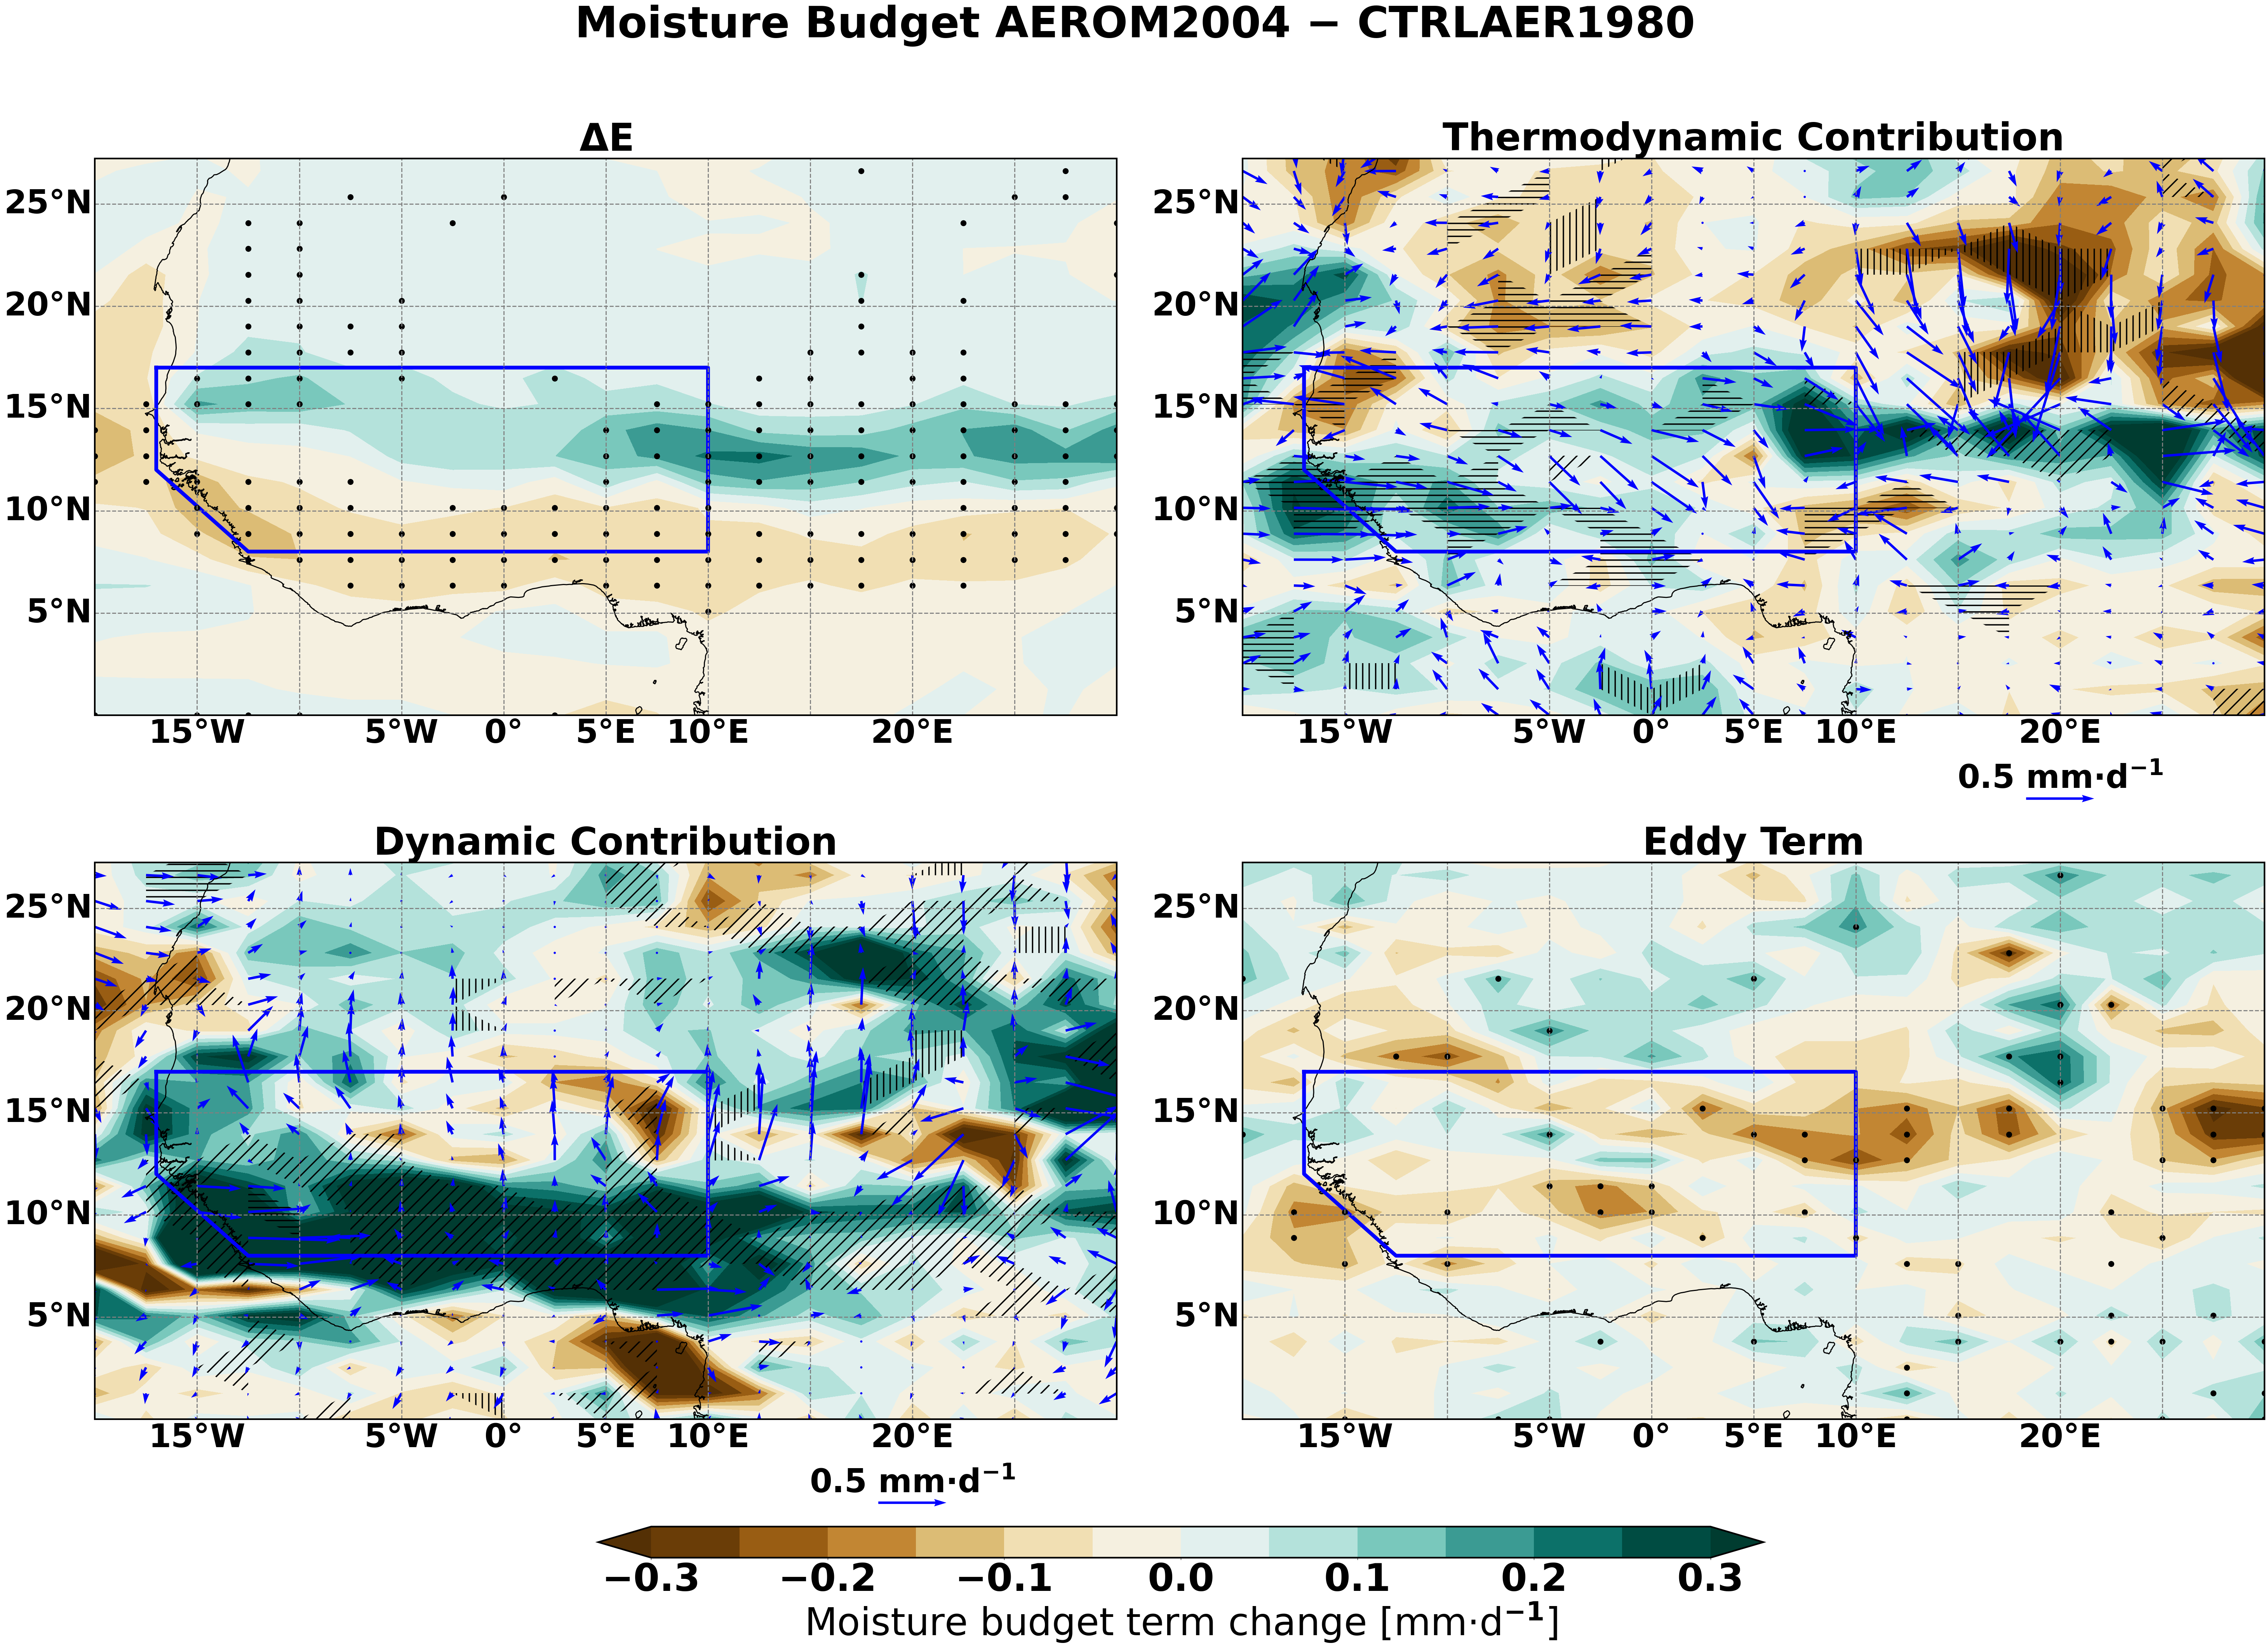

In [26]:
# Code to compute the maps appearing in the supplementary. Please change 

sahel_box = {'lat_min':8, 'lat_max':17, 'lon_min':-17, 'lon_max':10}
sahel_box_west = {'lat_min':12.5, 'lat_max':17, 'lon_min':-17, 'lon_max':-10}
sahel_box_east = {'lat_min':8, 'lat_max':17, 'lon_min':5, 'lon_max':10}

vmin_value = -0.3
vmax_value = 0.35
alpha = 0.05

levs = np.arange(vmin_value, vmax_value, sep)


ds_rep_terms = moisture_budget_terms_aerom2004_mean # Change this field to represent each moisture budget


font = {'family' : 'calibri',
       'weight': 'bold',
       'size': 60}
plt.rc('font', **font)
plt.rc('axes',edgecolor='k',linewidth=3)

fig = plt.figure(figsize=(60,40))
extent = [-20 + 360,30,0,25]

ft = 70

ax1 = fig.add_subplot(2,2,1, projection = ccrs.PlateCarree(0))
ax1.coastlines(resolution='10m', linewidth = 2)

cax_1=ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, (ds_rep_terms.evap) * 86400,  levels = levs, cmap='BrBG', extend = 'both', transform=ccrs.PlateCarree())

ax1.plot([sahel_box['lon_min'], sahel_box['lon_max'], sahel_box['lon_max'], -12.5, sahel_box['lon_min'], sahel_box['lon_min']],  [sahel_box['lat_max'], sahel_box['lat_max'], sahel_box['lat_min'], sahel_box['lat_min'], 12, sahel_box['lat_max']], linewidth = 7, color = 'blue')
#ax1.plot([sahel_box_east['lon_min'], sahel_box_east['lon_max'], sahel_box_east['lon_max'], sahel_box_east['lon_min'], sahel_box_east['lon_min']],  [sahel_box_east['lat_max'], sahel_box_east['lat_max'], sahel_box_east['lat_min'], sahel_box_east['lat_min'], sahel_box_east['lat_max']], linewidth = 7, color = 'purple')
#ax1.plot([sahel_box_west['lon_min'], sahel_box_west['lon_max'], sahel_box_west['lon_max'], -15, sahel_box_west['lon_min'], sahel_box_west['lon_min']],  [sahel_box_west['lat_max'], sahel_box_west['lat_max'], sahel_box_west['lat_min'], sahel_box_west['lat_min'], 12.5, sahel_box_west['lat_max']], linewidth = 7, color = 'orange')


LON, LAT = np.meshgrid(ds_rep_terms.lon.values, ds_rep_terms.lat.values)
lon_masked = ma.masked_where((np.isnan(p_value_aerom_evap)) | (p_value_aerom_evap > 0.05), LON)
lat_masked = ma.masked_where((np.isnan(p_value_aerom_evap)) | (p_value_aerom_evap > 0.05), LAT)


hatch = ax1.plot(np.transpose(lon_masked),np.transpose(lat_masked),'.',color='black',markersize=20)



ax1.set_title(r'$\Delta$E', weight = 'bold', fontsize = ft)
ax1.set_extent(extent)
gl = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', linewidth=2)
gl.xlocator = MultipleLocator(5)
gl.ylocator = MultipleLocator(5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
plt.rc('xtick', labelsize=40)
plt.rc('ytick', labelsize=40)







ax1 = fig.add_subplot(2,2,2, projection = ccrs.PlateCarree(0))
ax1.coastlines(resolution='10m', linewidth = 2)

cax_1=ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, ds_rep_terms.therm_cont  * 86400,  levels = levs, cmap='BrBG', extend = 'both', transform=ccrs.PlateCarree())



ax1.plot([sahel_box['lon_min'], sahel_box['lon_max'], sahel_box['lon_max'], -12.5, sahel_box['lon_min'], sahel_box['lon_min']],  [sahel_box['lat_max'], sahel_box['lat_max'], sahel_box['lat_min'], sahel_box['lat_min'], 12, sahel_box['lat_max']], linewidth = 7, color = 'blue')
#ax1.plot([sahel_box_east['lon_min'], sahel_box_east['lon_max'], sahel_box_east['lon_max'], sahel_box_east['lon_min'], sahel_box_east['lon_min']],  [sahel_box_east['lat_max'], sahel_box_east['lat_max'], sahel_box_east['lat_min'], sahel_box_east['lat_min'], sahel_box_east['lat_max']], linewidth = 7, color = 'purple')
#ax1.plot([sahel_box_west['lon_min'], sahel_box_west['lon_max'], sahel_box_west['lon_max'], -15, sahel_box_west['lon_min'], sahel_box_west['lon_min']],  [sahel_box_west['lat_max'], sahel_box_west['lat_max'], sahel_box_west['lat_min'], sahel_box_west['lat_min'], 12.5, sahel_box_west['lat_max']], linewidth = 7, color = 'orange')


#LON, LAT = np.meshgrid(ds_rep_terms.lon.values, ds_rep_terms.lat.values)
#lon_masked = ma.masked_where((np.isnan(p_value_ctrlghg_)) | (p_value_ctrlghg_evap > 0.05), LON)
#lat_masked = ma.masked_where((np.isnan(p_value_ctrlghg_evap)) | (p_value_ctrlghg_evap > 0.05), LAT)
#hatch = ax1.plot(np.transpose(lon_masked),np.transpose(lat_masked),'.',color='black',markersize=20)





LON, LAT = np.meshgrid(ds_rep_terms.lon.values, ds_rep_terms.lat.values)

#result = np.where(np.abs(A) >= np.abs(B), A, B_dom)

#lon_masked_divdq = ma.masked_where((np.abs(ds_rep_terms.ADVdQ) > np.abs(ds_rep_terms.DIVdQ)) , LON)
#lon_masked_advdq = ma.masked_where((np.abs(ds_rep_terms.ADVdQ) < np.abs(ds_rep_terms.DIVdQ)) , LON)

#lon_masked_advdq_x = ma.masked_where((np.abs(ds_rep_terms.ADVdQ_x) < np.abs(ds_rep_terms.ADVdQ)) , lon_masked_advdq)
#lon_masked_advdq_y = ma.masked_where((np.abs(ds_rep_terms.ADVdQ_y) < np.abs(ds_rep_terms.ADVdQ)) , lon_masked_advdq)



lon_masked_divdq = ma.masked_where((np.abs(ds_rep_terms.DIVdQ) / (np.abs(ds_rep_terms.ADVdQ) + np.abs(ds_rep_terms.DIVdQ)) < 0.6) , LON)
lon_masked_divdq = ma.masked_where((np.isnan(p_value_aerom_therm_cont)) | (p_value_aerom_therm_cont > alpha), lon_masked_divdq)


lon_masked_advdq = ma.masked_where((np.abs(ds_rep_terms.ADVdQ) / (np.abs(ds_rep_terms.ADVdQ) + np.abs(ds_rep_terms.DIVdQ)) < 0.6) , LON)

lon_masked_advdq_x = ma.masked_where((np.abs(ds_rep_terms.ADVdQ_x)) / (np.abs(ds_rep_terms.ADVdQ_x) + np.abs(ds_rep_terms.ADVdQ_y)) < 0.6 , lon_masked_advdq)
lon_masked_advdq_x = ma.masked_where((np.isnan(p_value_aerom_therm_cont)) | (p_value_aerom_therm_cont > alpha), lon_masked_advdq_x)

lon_masked_advdq_y = ma.masked_where((np.abs(ds_rep_terms.ADVdQ_y)) / (np.abs(ds_rep_terms.ADVdQ_x) + np.abs(ds_rep_terms.ADVdQ_y)) < 0.6 , lon_masked_advdq)
lon_masked_advdq_y = ma.masked_where((np.isnan(p_value_aerom_therm_cont)) | (p_value_aerom_therm_cont > alpha), lon_masked_advdq_y)




hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_divdq, colors='none', hatches=['/'], color = 'red',transform=ccrs.PlateCarree())

hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_advdq_x, colors='none', hatches=['-'], transform=ccrs.PlateCarree())

hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_advdq_y, colors='none', hatches=['|'], transform=ccrs.PlateCarree())


plt.rcParams['hatch.linewidth'] = 2.5

Q = ax1.quiver(LON, LAT, ds_rep_terms.ADVdQ_x, ds_rep_terms.ADVdQ_y, color = 'blue', scale = 1/20000)
ax1.quiverkey(Q,0.8,-0.15,1/300000, '0.5 mm·d$^{-1}$') 



ax1.set_title(r'Thermodynamic Contribution', weight = 'bold', fontsize = ft)
ax1.set_extent(extent)
gl = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', linewidth=2)
gl.xlocator = MultipleLocator(5)
gl.ylocator = MultipleLocator(5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
plt.rc('xtick', labelsize=40)
plt.rc('ytick', labelsize=40)




ax1 = fig.add_subplot(2,2,3, projection = ccrs.PlateCarree(0))
ax1.coastlines(resolution='10m', linewidth = 2)

cax_1=ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, ds_rep_terms.dyn_cont  * 86400 ,  levels = levs, cmap='BrBG', extend = 'both', transform=ccrs.PlateCarree())



ax1.plot([sahel_box['lon_min'], sahel_box['lon_max'], sahel_box['lon_max'], -12.5, sahel_box['lon_min'], sahel_box['lon_min']],  [sahel_box['lat_max'], sahel_box['lat_max'], sahel_box['lat_min'], sahel_box['lat_min'], 12, sahel_box['lat_max']], linewidth = 7, color = 'blue')
#ax1.plot([sahel_box_east['lon_min'], sahel_box_east['lon_max'], sahel_box_east['lon_max'], sahel_box_east['lon_min'], sahel_box_east['lon_min']],  [sahel_box_east['lat_max'], sahel_box_east['lat_max'], sahel_box_east['lat_min'], sahel_box_east['lat_min'], sahel_box_east['lat_max']], linewidth = 7, color = 'purple')
#ax1.plot([sahel_box_west['lon_min'], sahel_box_west['lon_max'], sahel_box_west['lon_max'], -15, sahel_box_west['lon_min'], sahel_box_west['lon_min']],  [sahel_box_west['lat_max'], sahel_box_west['lat_max'], sahel_box_west['lat_min'], sahel_box_west['lat_min'], 12.5, sahel_box_west['lat_max']], linewidth = 7, color = 'orange')


LON, LAT = np.meshgrid(ds_rep_terms.lon.values, ds_rep_terms.lat.values)

lon_masked_divdu = ma.masked_where((np.abs(ds_rep_terms.DIVdU) / (np.abs(ds_rep_terms.ADVdU) + np.abs(ds_rep_terms.DIVdU)) < 0.6) , LON)
lon_masked_divdu = ma.masked_where((np.isnan(p_value_aerom_dyn_cont)) | (p_value_aerom_dyn_cont > alpha), lon_masked_divdu)


lon_masked_advdu = ma.masked_where((np.abs(ds_rep_terms.ADVdU) / (np.abs(ds_rep_terms.ADVdU) + np.abs(ds_rep_terms.DIVdU)) < 0.6) , LON)

lon_masked_advdu_x = ma.masked_where((np.abs(ds_rep_terms.ADVdU_x)) / (np.abs(ds_rep_terms.ADVdU_x) + np.abs(ds_rep_terms.ADVdU_y)) < 0.6 , lon_masked_advdu)
lon_masked_advdu_x = ma.masked_where((np.isnan(p_value_aerom_dyn_cont)) | (p_value_aerom_dyn_cont > alpha), lon_masked_advdu_x)

lon_masked_advdu_y = ma.masked_where((np.abs(ds_rep_terms.ADVdU_y)) / (np.abs(ds_rep_terms.ADVdU_x) + np.abs(ds_rep_terms.ADVdU_y)) < 0.6 , lon_masked_advdu)
lon_masked_advdu_y = ma.masked_where((np.isnan(p_value_aerom_dyn_cont)) | (p_value_aerom_dyn_cont > alpha), lon_masked_advdu_y)



hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_divdu, colors='none', hatches=['/'], transform=ccrs.PlateCarree())



hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_advdu_x, colors='none', hatches=['-'], transform=ccrs.PlateCarree())

hatch = ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, lon_masked_advdu_y, colors='none', hatches=['|'], transform=ccrs.PlateCarree())

plt.rcParams['hatch.linewidth'] = 2.5


Q = ax1.quiver(LON, LAT, ds_rep_terms.ADVdU_x, ds_rep_terms.ADVdU_y, color = 'blue', scale = 1/20000)
ax1.quiverkey(Q,0.8,-0.15,1/300000, '0.5 mm·d$^{-1}$') 


ax1.set_title(r'Dynamic Contribution', weight = 'bold', fontsize = ft)


ax1.set_extent(extent)
gl = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', linewidth=2)
gl.xlocator = MultipleLocator(5)
gl.ylocator = MultipleLocator(5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
plt.rc('xtick', labelsize=40)
plt.rc('ytick', labelsize=40)




ax1 = fig.add_subplot(2,2,4, projection = ccrs.PlateCarree(0))
ax1.coastlines(resolution='10m', linewidth = 2)

cax_1=ax1.contourf(ds_rep_terms.lon.values, ds_rep_terms.lat.values, ds_rep_terms.eddy  * 86400 ,  levels = levs, cmap='BrBG', extend = 'both', transform=ccrs.PlateCarree())



ax1.plot([sahel_box['lon_min'], sahel_box['lon_max'], sahel_box['lon_max'], -12.5, sahel_box['lon_min'], sahel_box['lon_min']],  [sahel_box['lat_max'], sahel_box['lat_max'], sahel_box['lat_min'], sahel_box['lat_min'], 12, sahel_box['lat_max']], linewidth = 7, color = 'blue')
#ax1.plot([sahel_box_east['lon_min'], sahel_box_east['lon_max'], sahel_box_east['lon_max'], sahel_box_east['lon_min'], sahel_box_east['lon_min']],  [sahel_box_east['lat_max'], sahel_box_east['lat_max'], sahel_box_east['lat_min'], sahel_box_east['lat_min'], sahel_box_east['lat_max']], linewidth = 7, color = 'purple')
#ax1.plot([sahel_box_west['lon_min'], sahel_box_west['lon_max'], sahel_box_west['lon_max'], -15, sahel_box_west['lon_min'], sahel_box_west['lon_min']],  [sahel_box_west['lat_max'], sahel_box_west['lat_max'], sahel_box_west['lat_min'], sahel_box_west['lat_min'], 12.5, sahel_box_west['lat_max']], linewidth = 7, color = 'orange')



LON, LAT = np.meshgrid(ds_rep_terms.lon.values, ds_rep_terms.lat.values)
lon_masked = ma.masked_where((np.isnan(p_value_aerom_eddy)) | (p_value_aerom_eddy > alpha), LON)
lat_masked = ma.masked_where((np.isnan(p_value_aerom_eddy)) | (p_value_aerom_eddy > alpha), LAT)
hatch = ax1.plot(np.transpose(lon_masked),np.transpose(lat_masked),'.',color='black',markersize=20)





ax1.set_title(r'Eddy Term', weight = 'bold', fontsize = ft)


ax1.set_extent(extent)
gl = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', linewidth=2)
gl.xlocator = MultipleLocator(5)
gl.ylocator = MultipleLocator(5)
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
plt.rc('xtick', labelsize=40)
plt.rc('ytick', labelsize=40)






fig.subplots_adjust(bottom=0.1)
cbar_ax = fig.add_axes([0.27, -0.02, 0.5, 0.02])
cbar = fig.colorbar(cax_1, cax=cbar_ax, orientation = 'horizontal')
cbar.set_label(r'Moisture budget term change [mm·d$^{-1}$]', fontsize=ft)
cbar.ax.tick_params(labelsize=ft)

fig.suptitle('Moisture Budget AEROM2004 $-$ CTRLAER1980',fontsize = ft+10, color = 'black',weight = 'bold')



fig.tight_layout()

plt.savefig('/home/pfernand/Postdoc/Results/Forced_simulations/AER/Moisture_budget/Moisture_budget_AEROM2004_CTRLAER1980_therm_dyn_bwc.jpg', bbox_inches = 'tight', dpi = 150)





### Plot the bar diagrams

In [ ]:
ds_mb_ctrlghg2004 = moisture_budget_ctrlghg2004_time
ds_mb_ghgda2004 = moisture_budget_ghgda2004_time
ds_mb_ghgom2004 = moisture_budget_ghgom2004_time

ds_mb_ctrlghg2004_mean = moisture_budget_terms_ctrlghg2004_mean
ds_mb_ghgda2004_mean = moisture_budget_terms_ghgda2004_mean
ds_mb_ghgom2004_mean = moisture_budget_terms_ghgom2004_mean


ds_mb_ctrlaer2004 = moisture_budget_ctrlaer2004_time
ds_mb_aerda2004 = moisture_budget_aerda2004_time
ds_mb_aerom2004 = moisture_budget_aerom2004_time

ds_mb_ctrlaer2004_mean = moisture_budget_terms_ctrlaer2004_mean
ds_mb_aerda2004_mean = moisture_budget_terms_aerda2004_mean
ds_mb_aerom2004_mean = moisture_budget_terms_aerom2004_mean

In [19]:
# Compute area weighted means in the different boxes

sea_mask = sea_mask_creator(ds_mb_ctrlghg2004)


########### For GHG ##############

ds_mb_ctrlghg2004_land = ds_mb_ctrlghg2004.where(sea_mask == 0)
ds_mb_ghgda2004_land = ds_mb_ghgda2004.where(sea_mask == 0)
ds_mb_ghgom2004_land = ds_mb_ghgom2004.where(sea_mask == 0)

ds_mb_ctrlghg2004_mean_land = ds_mb_ctrlghg2004_mean.where(sea_mask == 0)
ds_mb_ghgda2004_mean_land = ds_mb_ghgda2004_mean.where(sea_mask == 0)
ds_mb_ghgom2004_mean_land = ds_mb_ghgom2004_mean.where(sea_mask == 0)

# Means in the East and West Sahel

ds_mb_ctrlghg2004_es = area_weighted_mean(ds_mb_ctrlghg2004_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ctrlghg2004_ws = area_weighted_mean(ds_mb_ctrlghg2004_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")


ds_mb_ghgda2004_es = area_weighted_mean(ds_mb_ghgda2004_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ghgda2004_ws = area_weighted_mean(ds_mb_ghgda2004_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")


ds_mb_ghgom2004_es = area_weighted_mean(ds_mb_ghgom2004_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ghgom2004_ws = area_weighted_mean(ds_mb_ghgom2004_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")


# Calculo medias con los datos promediados inicialmente

ds_mb_ctrlghg2004_mean_es = area_weighted_mean(ds_mb_ctrlghg2004_mean_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ctrlghg2004_mean_ws = area_weighted_mean(ds_mb_ctrlghg2004_mean_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")


ds_mb_ghgda2004_mean_es = area_weighted_mean(ds_mb_ghgda2004_mean_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ghgda2004_mean_ws = area_weighted_mean(ds_mb_ghgda2004_mean_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")


ds_mb_ghgom2004_mean_es = area_weighted_mean(ds_mb_ghgom2004_mean_land.sel(lat = slice(sahel_box_east['lat_min'], sahel_box_east['lat_max']), lon = slice(sahel_box_east['lon_min'], sahel_box_east['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_ghgom2004_mean_ws = area_weighted_mean(ds_mb_ghgom2004_mean_land.sel(lat = slice(sahel_box_west['lat_min'], sahel_box_west['lat_max']), lon = slice(sahel_box_west['lon_min'], sahel_box_west['lon_max'])), lat_name = "lat", lon_name = "lon")



########### For AA ##################


ds_mb_ctrlaer2004_land = ds_mb_ctrlaer2004.where(sea_mask == 0)
ds_mb_aerda2004_land = ds_mb_aerda2004.where(sea_mask == 0)
ds_mb_aerom2004_land = ds_mb_aerom2004.where(sea_mask == 0)

ds_mb_ctrlaer2004_mean_land = ds_mb_ctrlaer2004_mean.where(sea_mask == 0)
ds_mb_aerda2004_mean_land = ds_mb_aerda2004_mean.where(sea_mask == 0)
ds_mb_aerom2004_mean_land = ds_mb_aerom2004_mean.where(sea_mask == 0)

# Y hago medias en el East Sahel y West Sahel 

ds_mb_ctrlaer2004 = area_weighted_mean(ds_mb_ctrlaer2004_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_aerda2004 = area_weighted_mean(ds_mb_aerda2004_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_aerom2004 = area_weighted_mean(ds_mb_aerom2004_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")

# Calculo medias con los datos promediados inicialmente

ds_mb_ctrlaer2004_mean = area_weighted_mean(ds_mb_ctrlaer2004_mean_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_aerda2004_mean = area_weighted_mean(ds_mb_aerda2004_mean_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")
ds_mb_aerom2004_mean = area_weighted_mean(ds_mb_aerom2004_mean_land.sel(lat = slice(sahel_box['lat_min'], sahel_box['lat_max']), lon = slice(sahel_box['lon_min'], sahel_box['lon_max'])), lat_name = "lat", lon_name = "lon")





Creating sea mask: 100%|██████████| 20592/20592 [00:19<00:00, 1038.23it/s]


In [20]:
# Calculo los intervalos de confianza

from scipy.stats import ttest_ind
alpha = 0.05

################## PARA LOS GHG #################

############ PARA CTRL ################

ci_precip_ctrlghg2004_es = np.asarray(ttest_ind(ds_mb_ctrlghg2004_es.precip_2, ds_mb_ctrlghg2004_es.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ctrlghg2004_es = np.asarray(ttest_ind(ds_mb_ctrlghg2004_es.evap_2, ds_mb_ctrlghg2004_es.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ctrlghg2004_es = np.asarray(ttest_ind(ds_mb_ctrlghg2004_es.therm_cont_2, ds_mb_ctrlghg2004_es.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ctrlghg2004_es = np.asarray(ttest_ind(ds_mb_ctrlghg2004_es.dyn_cont_2, ds_mb_ctrlghg2004_es.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ctrlghg2004_es = np.asarray(ttest_ind(ds_mb_ctrlghg2004_es.eddy_2, ds_mb_ctrlghg2004_es.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ctrlghg2004_es = np.abs(ci_precip_ctrlghg2004_es - (np.nanmean(ds_mb_ctrlghg2004_es.precip_2) - np.nanmean(ds_mb_ctrlghg2004_es.precip_1)) * 86400)
yerr_evap_ctrlghg2004_es = np.abs(ci_evap_ctrlghg2004_es - (np.nanmean(ds_mb_ctrlghg2004_es.evap_2) - np.nanmean(ds_mb_ctrlghg2004_es.evap_1)) * 86400)
yerr_therm_cont_ctrlghg2004_es = np.abs(ci_therm_cont_ctrlghg2004_es - (np.nanmean(ds_mb_ctrlghg2004_es.therm_cont_2) - np.nanmean(ds_mb_ctrlghg2004_es.therm_cont_1)) * 86400)
yerr_dyn_cont_ctrlghg2004_es = np.abs(ci_dyn_cont_ctrlghg2004_es - (np.nanmean(ds_mb_ctrlghg2004_es.dyn_cont_2) - np.nanmean(ds_mb_ctrlghg2004_es.dyn_cont_1)) * 86400)
yerr_eddy_ctrlghg2004_es = np.abs(ci_eddy_ctrlghg2004_es - (np.nanmean(ds_mb_ctrlghg2004_es.eddy_2) - np.nanmean(ds_mb_ctrlghg2004_es.eddy_1)) * 86400)



ci_precip_ctrlghg2004_ws = np.asarray(ttest_ind(ds_mb_ctrlghg2004_ws.precip_2, ds_mb_ctrlghg2004_ws.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ctrlghg2004_ws = np.asarray(ttest_ind(ds_mb_ctrlghg2004_ws.evap_2, ds_mb_ctrlghg2004_ws.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ctrlghg2004_ws = np.asarray(ttest_ind(ds_mb_ctrlghg2004_ws.therm_cont_2, ds_mb_ctrlghg2004_ws.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ctrlghg2004_ws = np.asarray(ttest_ind(ds_mb_ctrlghg2004_ws.dyn_cont_2, ds_mb_ctrlghg2004_ws.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ctrlghg2004_ws = np.asarray(ttest_ind(ds_mb_ctrlghg2004_ws.eddy_2, ds_mb_ctrlghg2004_ws.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ctrlghg2004_ws = np.abs(ci_precip_ctrlghg2004_ws - (np.nanmean(ds_mb_ctrlghg2004_ws.precip_2) - np.nanmean(ds_mb_ctrlghg2004_ws.precip_1)) * 86400)
yerr_evap_ctrlghg2004_ws = np.abs(ci_evap_ctrlghg2004_ws - (np.nanmean(ds_mb_ctrlghg2004_ws.evap_2) - np.nanmean(ds_mb_ctrlghg2004_ws.evap_1)) * 86400)
yerr_therm_cont_ctrlghg2004_ws = np.abs(ci_therm_cont_ctrlghg2004_ws - (np.nanmean(ds_mb_ctrlghg2004_ws.therm_cont_2) - np.nanmean(ds_mb_ctrlghg2004_ws.therm_cont_1)) * 86400)
yerr_dyn_cont_ctrlghg2004_ws = np.abs(ci_dyn_cont_ctrlghg2004_ws - (np.nanmean(ds_mb_ctrlghg2004_ws.dyn_cont_2) - np.nanmean(ds_mb_ctrlghg2004_ws.dyn_cont_1)) * 86400)
yerr_eddy_ctrlghg2004_ws = np.abs(ci_eddy_ctrlghg2004_ws - (np.nanmean(ds_mb_ctrlghg2004_ws.eddy_2) - np.nanmean(ds_mb_ctrlghg2004_ws.eddy_1)) * 86400)


# Y los valores de las barras 

dprecip_ctrlghg2004_es = (np.nanmean(ds_mb_ctrlghg2004_mean_es.precip)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.precip_1)) * 86400
devap_ctrlghg2004_es = (np.nanmean(ds_mb_ctrlghg2004_mean_es.evap)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.evap_1)) * 86400
dtherm_cont_ctrlghg2004_es = (np.nanmean(ds_mb_ctrlghg2004_mean_es.therm_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_ctrlghg2004_es = (np.nanmean(ds_mb_ctrlghg2004_mean_es.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.dyn_cont_1)) * 86400
deddy_ctrlghg2004_es = (np.nanmean(ds_mb_ctrlghg2004_mean_es.eddy)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.eddy_1)) * 86400


dprecip_ctrlghg2004_ws = (np.nanmean(ds_mb_ctrlghg2004_mean_ws.precip)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_ws.precip_1)) * 86400
devap_ctrlghg2004_ws = (np.nanmean(ds_mb_ctrlghg2004_mean_ws.evap)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_ws.evap_1)) * 86400
dtherm_cont_ctrlghg2004_ws = (np.nanmean(ds_mb_ctrlghg2004_mean_ws.therm_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_ws.therm_cont_1)) * 86400
ddyn_cont_ctrlghg2004_ws = (np.nanmean(ds_mb_ctrlghg2004_mean_ws.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_ws.dyn_cont_1)) * 86400
deddy_ctrlghg2004_ws = (np.nanmean(ds_mb_ctrlghg2004_mean_ws.eddy)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_ws.eddy_1)) * 86400



######### PARA GHGDA ##################



ci_precip_ghgda2004_es = np.asarray(ttest_ind(ds_mb_ghgda2004_es.precip_2, ds_mb_ghgda2004_es.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ghgda2004_es = np.asarray(ttest_ind(ds_mb_ghgda2004_es.evap_2, ds_mb_ghgda2004_es.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ghgda2004_es = np.asarray(ttest_ind(ds_mb_ghgda2004_es.therm_cont_2, ds_mb_ghgda2004_es.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ghgda2004_es = np.asarray(ttest_ind(ds_mb_ghgda2004_es.dyn_cont_2, ds_mb_ghgda2004_es.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ghgda2004_es = np.asarray(ttest_ind(ds_mb_ghgda2004_es.eddy_2, ds_mb_ghgda2004_es.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ghgda2004_es = np.abs(ci_precip_ghgda2004_es - (np.nanmean(ds_mb_ghgda2004_es.precip_2) - np.nanmean(ds_mb_ghgda2004_es.precip_1)) * 86400)
yerr_evap_ghgda2004_es = np.abs(ci_evap_ghgda2004_es - (np.nanmean(ds_mb_ghgda2004_es.evap_2) - np.nanmean(ds_mb_ghgda2004_es.evap_1)) * 86400)
yerr_therm_cont_ghgda2004_es = np.abs(ci_therm_cont_ghgda2004_es - (np.nanmean(ds_mb_ghgda2004_es.therm_cont_2) - np.nanmean(ds_mb_ghgda2004_es.therm_cont_1)) * 86400)
yerr_dyn_cont_ghgda2004_es = np.abs(ci_dyn_cont_ghgda2004_es - (np.nanmean(ds_mb_ghgda2004_es.dyn_cont_2) - np.nanmean(ds_mb_ghgda2004_es.dyn_cont_1)) * 86400)
yerr_eddy_ghgda2004_es = np.abs(ci_eddy_ghgda2004_es - (np.nanmean(ds_mb_ghgda2004_es.eddy_2) - np.nanmean(ds_mb_ghgda2004_es.eddy_1)) * 86400)



ci_precip_ghgda2004_ws = np.asarray(ttest_ind(ds_mb_ghgda2004_ws.precip_2, ds_mb_ghgda2004_ws.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ghgda2004_ws = np.asarray(ttest_ind(ds_mb_ghgda2004_ws.evap_2, ds_mb_ghgda2004_ws.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ghgda2004_ws = np.asarray(ttest_ind(ds_mb_ghgda2004_ws.therm_cont_2, ds_mb_ghgda2004_ws.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ghgda2004_ws = np.asarray(ttest_ind(ds_mb_ghgda2004_ws.dyn_cont_2, ds_mb_ghgda2004_ws.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ghgda2004_ws = np.asarray(ttest_ind(ds_mb_ghgda2004_ws.eddy_2, ds_mb_ghgda2004_ws.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ghgda2004_ws = np.abs(ci_precip_ghgda2004_ws - (np.nanmean(ds_mb_ghgda2004_ws.precip_2) - np.nanmean(ds_mb_ghgda2004_ws.precip_1)) * 86400)
yerr_evap_ghgda2004_ws = np.abs(ci_evap_ghgda2004_ws - (np.nanmean(ds_mb_ghgda2004_ws.evap_2) - np.nanmean(ds_mb_ghgda2004_ws.evap_1)) * 86400)
yerr_therm_cont_ghgda2004_ws = np.abs(ci_therm_cont_ghgda2004_ws - (np.nanmean(ds_mb_ghgda2004_ws.therm_cont_2) - np.nanmean(ds_mb_ghgda2004_ws.therm_cont_1)) * 86400)
yerr_dyn_cont_ghgda2004_ws = np.abs(ci_dyn_cont_ghgda2004_ws - (np.nanmean(ds_mb_ghgda2004_ws.dyn_cont_2) - np.nanmean(ds_mb_ghgda2004_ws.dyn_cont_1)) * 86400)
yerr_eddy_ghgda2004_ws = np.abs(ci_eddy_ghgda2004_ws - (np.nanmean(ds_mb_ghgda2004_ws.eddy_2) - np.nanmean(ds_mb_ghgda2004_ws.eddy_1)) * 86400)



# Y los valores de las barras 

dprecip_ghgda2004_es = (np.nanmean(ds_mb_ghgda2004_mean_es.precip)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_es.precip_1)) * 86400
devap_ghgda2004_es = (np.nanmean(ds_mb_ghgda2004_mean_es.evap)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_es.evap_1)) * 86400
dtherm_cont_ghgda2004_es = (np.nanmean(ds_mb_ghgda2004_mean_es.therm_cont)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_ghgda2004_es = (np.nanmean(ds_mb_ghgda2004_mean_es.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_es.dyn_cont_1)) * 86400
deddy_ghgda2004_es = (np.nanmean(ds_mb_ghgda2004_mean_es.eddy)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_es.eddy_1)) * 86400


dprecip_ghgda2004_ws = (np.nanmean(ds_mb_ghgda2004_mean_ws.precip)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_ws.precip_1)) * 86400
devap_ghgda2004_ws = (np.nanmean(ds_mb_ghgda2004_mean_ws.evap)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_ws.evap_1)) * 86400
dtherm_cont_ghgda2004_ws = (np.nanmean(ds_mb_ghgda2004_mean_ws.therm_cont)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_ws.therm_cont_1)) * 86400
ddyn_cont_ghgda2004_ws = (np.nanmean(ds_mb_ghgda2004_mean_ws.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_ws.dyn_cont_1)) * 86400
deddy_ghgda2004_ws = (np.nanmean(ds_mb_ghgda2004_mean_ws.eddy)) * 86400 #- np.nanmean(ds_mb_ghgda2004_mean_ws.eddy_1)) * 86400


########### PARA GHGOM #############


ci_precip_ghgom2004_es = np.asarray(ttest_ind(ds_mb_ghgom2004_es.precip_2, ds_mb_ghgom2004_es.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ghgom2004_es = np.asarray(ttest_ind(ds_mb_ghgom2004_es.evap_2, ds_mb_ghgom2004_es.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ghgom2004_es = np.asarray(ttest_ind(ds_mb_ghgom2004_es.therm_cont_2, ds_mb_ghgom2004_es.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ghgom2004_es = np.asarray(ttest_ind(ds_mb_ghgom2004_es.dyn_cont_2, ds_mb_ghgom2004_es.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ghgom2004_es = np.asarray(ttest_ind(ds_mb_ghgom2004_es.eddy_2, ds_mb_ghgom2004_es.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ghgom2004_es = np.abs(ci_precip_ghgom2004_es - (np.nanmean(ds_mb_ghgom2004_es.precip_2) - np.nanmean(ds_mb_ghgom2004_es.precip_1)) * 86400)
yerr_evap_ghgom2004_es = np.abs(ci_evap_ghgom2004_es - (np.nanmean(ds_mb_ghgom2004_es.evap_2) - np.nanmean(ds_mb_ghgom2004_es.evap_1)) * 86400)
yerr_therm_cont_ghgom2004_es = np.abs(ci_therm_cont_ghgom2004_es - (np.nanmean(ds_mb_ghgom2004_es.therm_cont_2) - np.nanmean(ds_mb_ghgom2004_es.therm_cont_1)) * 86400)
yerr_dyn_cont_ghgom2004_es = np.abs(ci_dyn_cont_ghgom2004_es - (np.nanmean(ds_mb_ghgom2004_es.dyn_cont_2) - np.nanmean(ds_mb_ghgom2004_es.dyn_cont_1)) * 86400)
yerr_eddy_ghgom2004_es = np.abs(ci_eddy_ghgom2004_es - (np.nanmean(ds_mb_ghgom2004_es.eddy_2) - np.nanmean(ds_mb_ghgom2004_es.eddy_1)) * 86400)



ci_precip_ghgom2004_ws = np.asarray(ttest_ind(ds_mb_ghgom2004_ws.precip_2, ds_mb_ghgom2004_ws.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ghgom2004_ws = np.asarray(ttest_ind(ds_mb_ghgom2004_ws.evap_2, ds_mb_ghgom2004_ws.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ghgom2004_ws = np.asarray(ttest_ind(ds_mb_ghgom2004_ws.therm_cont_2, ds_mb_ghgom2004_ws.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ghgom2004_ws = np.asarray(ttest_ind(ds_mb_ghgom2004_ws.dyn_cont_2, ds_mb_ghgom2004_ws.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ghgom2004_ws = np.asarray(ttest_ind(ds_mb_ghgom2004_ws.eddy_2, ds_mb_ghgom2004_ws.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ghgom2004_ws = np.abs(ci_precip_ghgom2004_ws - (np.nanmean(ds_mb_ghgom2004_ws.precip_2) - np.nanmean(ds_mb_ghgom2004_ws.precip_1)) * 86400)
yerr_evap_ghgom2004_ws = np.abs(ci_evap_ghgom2004_ws - (np.nanmean(ds_mb_ghgom2004_ws.evap_2) - np.nanmean(ds_mb_ghgom2004_ws.evap_1)) * 86400)
yerr_therm_cont_ghgom2004_ws = np.abs(ci_therm_cont_ghgom2004_ws - (np.nanmean(ds_mb_ghgom2004_ws.therm_cont_2) - np.nanmean(ds_mb_ghgom2004_ws.therm_cont_1)) * 86400)
yerr_dyn_cont_ghgom2004_ws = np.abs(ci_dyn_cont_ghgom2004_ws - (np.nanmean(ds_mb_ghgom2004_ws.dyn_cont_2) - np.nanmean(ds_mb_ghgom2004_ws.dyn_cont_1)) * 86400)
yerr_eddy_ghgom2004_ws = np.abs(ci_eddy_ghgom2004_ws - (np.nanmean(ds_mb_ghgom2004_ws.eddy_2) - np.nanmean(ds_mb_ghgom2004_ws.eddy_1)) * 86400)


##### Y calculo los valores de las barras ###########

dprecip_ghgom2004_es = (np.nanmean(ds_mb_ghgom2004_mean_es.precip)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_es.precip_1)) * 86400
devap_ghgom2004_es = (np.nanmean(ds_mb_ghgom2004_mean_es.evap)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_es.evap_1)) * 86400
dtherm_cont_ghgom2004_es = (np.nanmean(ds_mb_ghgom2004_mean_es.therm_cont)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_ghgom2004_es = (np.nanmean(ds_mb_ghgom2004_mean_es.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_es.dyn_cont_1)) * 86400
deddy_ghgom2004_es = (np.nanmean(ds_mb_ghgom2004_mean_es.eddy)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_es.eddy_1)) * 86400


dprecip_ghgom2004_ws = (np.nanmean(ds_mb_ghgom2004_mean_ws.precip)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_ws.precip_1)) * 86400
devap_ghgom2004_ws = (np.nanmean(ds_mb_ghgom2004_mean_ws.evap)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_ws.evap_1)) * 86400
dtherm_cont_ghgom2004_ws = (np.nanmean(ds_mb_ghgom2004_mean_ws.therm_cont)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_ws.therm_cont_1)) * 86400
ddyn_cont_ghgom2004_ws = (np.nanmean(ds_mb_ghgom2004_mean_ws.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_ws.dyn_cont_1)) * 86400
deddy_ghgom2004_ws = (np.nanmean(ds_mb_ghgom2004_mean_ws.eddy)) * 86400 #- np.nanmean(ds_mb_ghgom2004_mean_ws.eddy_1)) * 86400



################### PARA LOS AEROSOLES #####################



############ PARA CTRL ################

ci_precip_ctrlaer2004 = np.asarray(ttest_ind(ds_mb_ctrlaer2004.precip_2, ds_mb_ctrlaer2004.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_ctrlaer2004 = np.asarray(ttest_ind(ds_mb_ctrlaer2004.evap_2, ds_mb_ctrlaer2004.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_ctrlaer2004 = np.asarray(ttest_ind(ds_mb_ctrlaer2004.therm_cont_2, ds_mb_ctrlaer2004.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_ctrlaer2004 = np.asarray(ttest_ind(ds_mb_ctrlaer2004.dyn_cont_2, ds_mb_ctrlaer2004.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_ctrlaer2004 = np.asarray(ttest_ind(ds_mb_ctrlaer2004.eddy_2, ds_mb_ctrlaer2004.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_ctrlaer2004 = np.abs(ci_precip_ctrlaer2004 - (np.nanmean(ds_mb_ctrlaer2004.precip_2) - np.nanmean(ds_mb_ctrlaer2004.precip_1)) * 86400)
yerr_evap_ctrlaer2004 = np.abs(ci_evap_ctrlaer2004 - (np.nanmean(ds_mb_ctrlaer2004.evap_2) - np.nanmean(ds_mb_ctrlaer2004.evap_1)) * 86400)
yerr_therm_cont_ctrlaer2004 = np.abs(ci_therm_cont_ctrlaer2004 - (np.nanmean(ds_mb_ctrlaer2004.therm_cont_2) - np.nanmean(ds_mb_ctrlaer2004.therm_cont_1)) * 86400)
yerr_dyn_cont_ctrlaer2004 = np.abs(ci_dyn_cont_ctrlaer2004 - (np.nanmean(ds_mb_ctrlaer2004.dyn_cont_2) - np.nanmean(ds_mb_ctrlaer2004.dyn_cont_1)) * 86400)
yerr_eddy_ctrlaer2004 = np.abs(ci_eddy_ctrlaer2004 - (np.nanmean(ds_mb_ctrlaer2004.eddy_2) - np.nanmean(ds_mb_ctrlaer2004.eddy_1)) * 86400)


# Y los valores de las barras 

dprecip_ctrlaer2004 = (np.nanmean(ds_mb_ctrlaer2004_mean.precip)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.precip_1)) * 86400
devap_ctrlaer2004 = (np.nanmean(ds_mb_ctrlaer2004_mean.evap)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.evap_1)) * 86400
dtherm_cont_ctrlaer2004 = (np.nanmean(ds_mb_ctrlaer2004_mean.therm_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_ctrlaer2004 = (np.nanmean(ds_mb_ctrlaer2004_mean.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.dyn_cont_1)) * 86400
deddy_ctrlaer2004 = (np.nanmean(ds_mb_ctrlaer2004_mean.eddy)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.eddy_1)) * 86400



############ PARA AERDA ################

ci_precip_aerda2004 = np.asarray(ttest_ind(ds_mb_aerda2004.precip_2, ds_mb_aerda2004.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_aerda2004 = np.asarray(ttest_ind(ds_mb_aerda2004.evap_2, ds_mb_aerda2004.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_aerda2004 = np.asarray(ttest_ind(ds_mb_aerda2004.therm_cont_2, ds_mb_aerda2004.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_aerda2004 = np.asarray(ttest_ind(ds_mb_aerda2004.dyn_cont_2, ds_mb_aerda2004.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_aerda2004 = np.asarray(ttest_ind(ds_mb_aerda2004.eddy_2, ds_mb_aerda2004.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_aerda2004 = np.abs(ci_precip_aerda2004 - (np.nanmean(ds_mb_aerda2004.precip_2) - np.nanmean(ds_mb_aerda2004.precip_1)) * 86400)
yerr_evap_aerda2004 = np.abs(ci_evap_aerda2004 - (np.nanmean(ds_mb_aerda2004.evap_2) - np.nanmean(ds_mb_aerda2004.evap_1)) * 86400)
yerr_therm_cont_aerda2004 = np.abs(ci_therm_cont_aerda2004 - (np.nanmean(ds_mb_aerda2004.therm_cont_2) - np.nanmean(ds_mb_aerda2004.therm_cont_1)) * 86400)
yerr_dyn_cont_aerda2004 = np.abs(ci_dyn_cont_aerda2004 - (np.nanmean(ds_mb_aerda2004.dyn_cont_2) - np.nanmean(ds_mb_aerda2004.dyn_cont_1)) * 86400)
yerr_eddy_aerda2004 = np.abs(ci_eddy_aerda2004 - (np.nanmean(ds_mb_aerda2004.eddy_2) - np.nanmean(ds_mb_aerda2004.eddy_1)) * 86400)


# Y los valores de las barras 

dprecip_aerda2004 = (np.nanmean(ds_mb_aerda2004_mean.precip)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.precip_1)) * 86400
devap_aerda2004 = (np.nanmean(ds_mb_aerda2004_mean.evap)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.evap_1)) * 86400
dtherm_cont_aerda2004 = (np.nanmean(ds_mb_aerda2004_mean.therm_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_aerda2004 = (np.nanmean(ds_mb_aerda2004_mean.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.dyn_cont_1)) * 86400
deddy_aerda2004 = (np.nanmean(ds_mb_aerda2004_mean.eddy)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.eddy_1)) * 86400



############ PARA AEROM ################

ci_precip_aerom2004 = np.asarray(ttest_ind(ds_mb_aerom2004.precip_2, ds_mb_aerom2004.precip_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_evap_aerom2004 = np.asarray(ttest_ind(ds_mb_aerom2004.evap_2, ds_mb_aerom2004.evap_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_therm_cont_aerom2004 = np.asarray(ttest_ind(ds_mb_aerom2004.therm_cont_2, ds_mb_aerom2004.therm_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_dyn_cont_aerom2004 = np.asarray(ttest_ind(ds_mb_aerom2004.dyn_cont_2, ds_mb_aerom2004.dyn_cont_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 
ci_eddy_aerom2004 = np.asarray(ttest_ind(ds_mb_aerom2004.eddy_2, ds_mb_aerom2004.eddy_1, equal_var=False).confidence_interval(confidence_level=alpha)[:]) * 86400 

yerr_precip_aerom2004 = np.abs(ci_precip_aerom2004 - (np.nanmean(ds_mb_aerom2004.precip_2) - np.nanmean(ds_mb_aerom2004.precip_1)) * 86400)
yerr_evap_aerom2004 = np.abs(ci_evap_aerom2004 - (np.nanmean(ds_mb_aerom2004.evap_2) - np.nanmean(ds_mb_aerom2004.evap_1)) * 86400)
yerr_therm_cont_aerom2004 = np.abs(ci_therm_cont_aerom2004 - (np.nanmean(ds_mb_aerom2004.therm_cont_2) - np.nanmean(ds_mb_aerom2004.therm_cont_1)) * 86400)
yerr_dyn_cont_aerom2004 = np.abs(ci_dyn_cont_aerom2004 - (np.nanmean(ds_mb_aerom2004.dyn_cont_2) - np.nanmean(ds_mb_aerom2004.dyn_cont_1)) * 86400)
yerr_eddy_aerom2004 = np.abs(ci_eddy_aerom2004 - (np.nanmean(ds_mb_aerom2004.eddy_2) - np.nanmean(ds_mb_aerom2004.eddy_1)) * 86400)


# Y los valores de las barras 

dprecip_aerom2004 = (np.nanmean(ds_mb_aerom2004_mean.precip)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.precip_1)) * 86400
devap_aerom2004 = (np.nanmean(ds_mb_aerom2004_mean.evap)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.evap_1)) * 86400
dtherm_cont_aerom2004 = (np.nanmean(ds_mb_aerom2004_mean.therm_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.therm_cont_1)) * 86400
ddyn_cont_aerom2004 = (np.nanmean(ds_mb_aerom2004_mean.dyn_cont)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.dyn_cont_1)) * 86400
deddy_aerom2004 = (np.nanmean(ds_mb_aerom2004_mean.eddy)) * 86400 #- np.nanmean(ds_mb_ctrlghg2004_mean_es.eddy_1)) * 86400







In [21]:
# Put them in an error matrix

########### PARA LOS GHG #########
yerr_ctrlghg_es = np.vstack([yerr_precip_ctrlghg2004_es, yerr_evap_ctrlghg2004_es, yerr_therm_cont_ctrlghg2004_es, yerr_dyn_cont_ctrlghg2004_es, yerr_eddy_ctrlghg2004_es]).transpose()
yerr_ctrlghg_ws = np.vstack([yerr_precip_ctrlghg2004_ws, yerr_evap_ctrlghg2004_ws, yerr_therm_cont_ctrlghg2004_ws, yerr_dyn_cont_ctrlghg2004_ws, yerr_eddy_ctrlghg2004_ws]).transpose()

yerr_ghgda_es = np.vstack([yerr_precip_ghgda2004_es, yerr_evap_ghgda2004_es, yerr_therm_cont_ghgda2004_es, yerr_dyn_cont_ghgda2004_es, yerr_eddy_ghgda2004_es]).transpose()
yerr_ghgda_ws = np.vstack([yerr_precip_ghgda2004_ws, yerr_evap_ghgda2004_ws, yerr_therm_cont_ghgda2004_ws, yerr_dyn_cont_ghgda2004_ws, yerr_eddy_ghgda2004_ws]).transpose()

yerr_ghgom_es = np.vstack([yerr_precip_ghgom2004_es, yerr_evap_ghgom2004_es, yerr_therm_cont_ghgom2004_es, yerr_dyn_cont_ghgom2004_es, yerr_eddy_ghgom2004_es]).transpose()
yerr_ghgom_ws = np.vstack([yerr_precip_ghgom2004_ws, yerr_evap_ghgom2004_ws, yerr_therm_cont_ghgom2004_ws, yerr_dyn_cont_ghgom2004_ws, yerr_eddy_ghgom2004_ws]).transpose()


############## PARA LOS AA###########
yerr_ctrlaer = np.vstack([yerr_precip_ctrlaer2004, yerr_evap_ctrlaer2004, yerr_therm_cont_ctrlaer2004, yerr_dyn_cont_ctrlaer2004, yerr_eddy_ctrlaer2004]).transpose()
yerr_aerda = np.vstack([yerr_precip_aerda2004, yerr_evap_aerda2004, yerr_therm_cont_aerda2004, yerr_dyn_cont_aerda2004, yerr_eddy_aerda2004]).transpose()
yerr_aerom = np.vstack([yerr_precip_aerom2004, yerr_evap_aerom2004, yerr_therm_cont_aerom2004, yerr_dyn_cont_aerom2004, yerr_eddy_aerom2004]).transpose()


findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: F

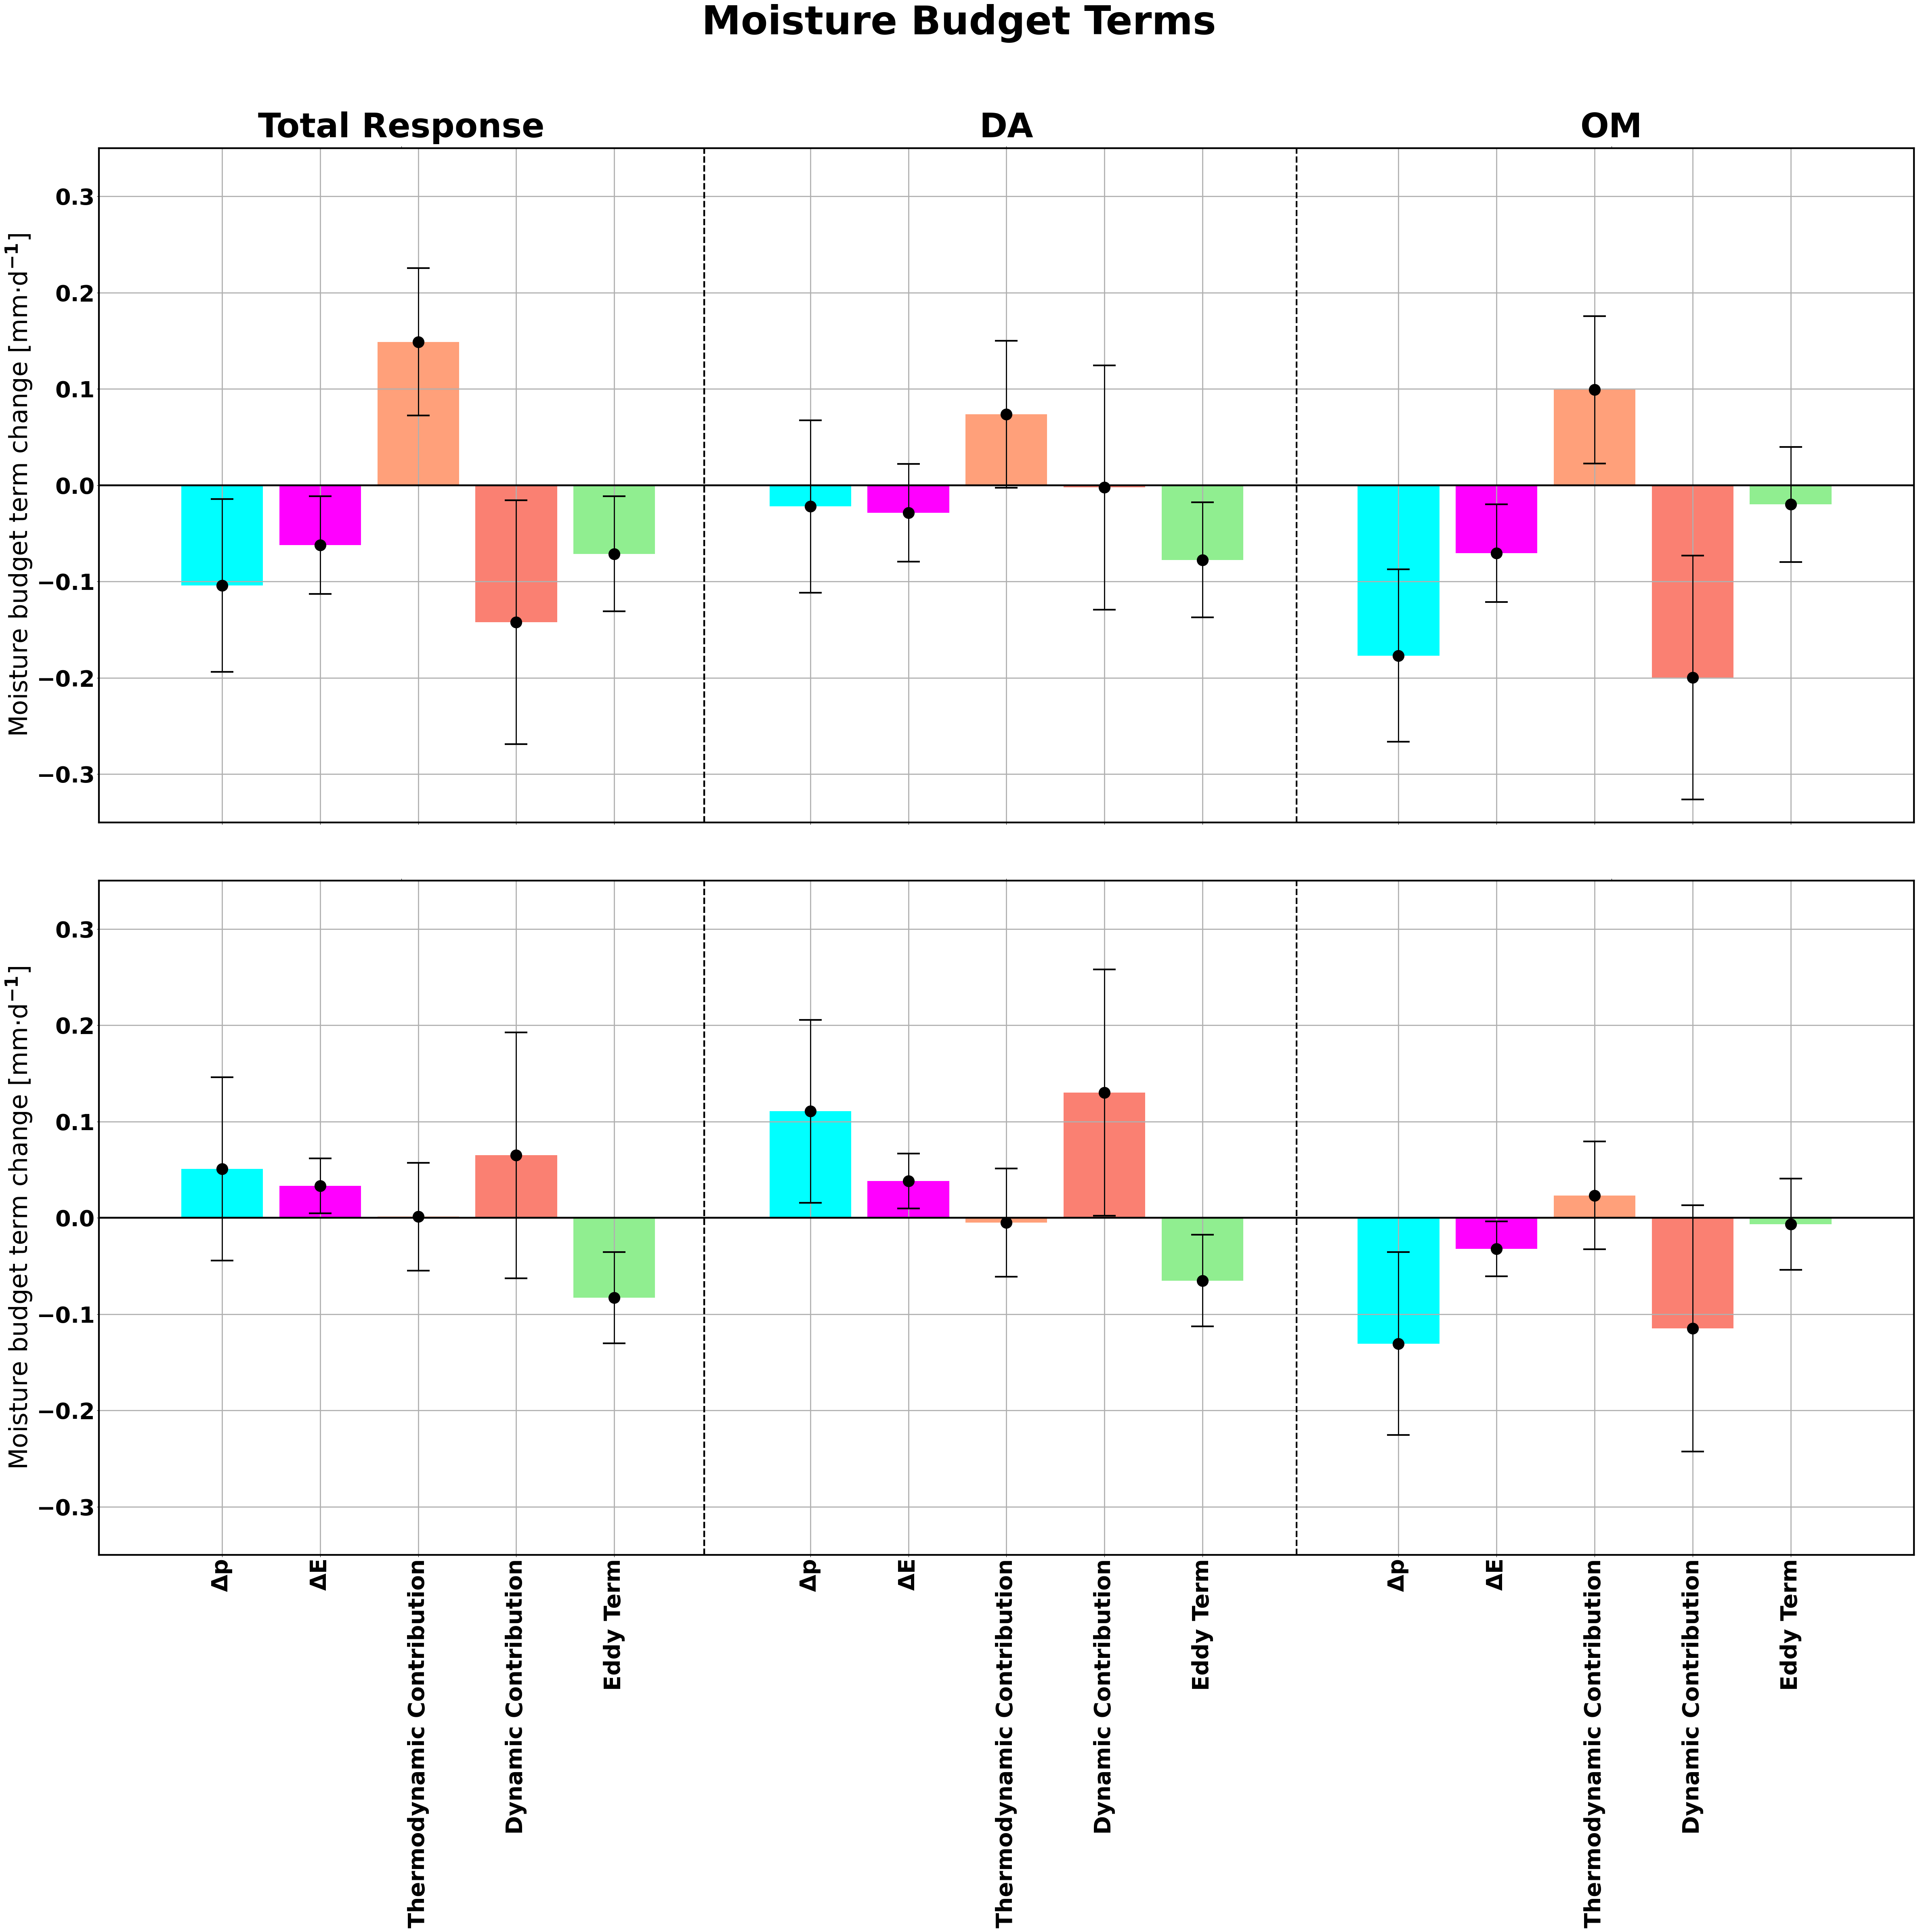

In [54]:
######### BAR DIAGRAM FOR GHG ##################

fig = plt.figure(figsize=(50,50))
ft = 70

size_bars = 1
sep_groups = 0
location_vector_diff12_bar = np.asarray([size_bars/2 + 0.1, 3 * size_bars/2 + 0.3, 5 * size_bars/2 + 0.5, 7 * size_bars/2 + 0.7, 9 * size_bars/2 + 0.9])
location_vector_diff32_bar = np.asarray([11 * size_bars/2 + 1.3 +1, 13 * size_bars/2 + 1.5+1, 15 * size_bars/2 + 1.7+1,17 * size_bars/2 + 1.9+1,19 * size_bars/2 + 2.1+1])
location_vector_diff52_bar = np.asarray([21 * size_bars/2 + 2.5 +2, 23 * size_bars/2 + 2.7+2, 25 * size_bars/2 + 2.9+2,27 * size_bars/2 + 3.1+2,29 * size_bars/2 + 3.3+2])

# Calculo vectores de máscara para representar la significación estadística



color = ['cyan', 'magenta', 'lightsalmon', 'salmon', 'lightgreen', 'green', 'blue', 'red','orange']


ax1 = fig.add_subplot(2,1,1)


ax1.bar(location_vector_diff12_bar, [dprecip_ctrlghg2004_ws, devap_ctrlghg2004_ws, dtherm_cont_ctrlghg2004_ws, ddyn_cont_ctrlghg2004_ws, deddy_ctrlghg2004_ws] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff32_bar, [dprecip_ghgda2004_ws, devap_ghgda2004_ws, dtherm_cont_ghgda2004_ws,  ddyn_cont_ghgda2004_ws, deddy_ghgda2004_ws] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff52_bar, [dprecip_ghgom2004_ws, devap_ghgom2004_ws, dtherm_cont_ghgom2004_ws,  ddyn_cont_ghgom2004_ws, deddy_ghgom2004_ws] , width = size_bars, align = 'center', color = color)



ax1.errorbar(location_vector_diff12_bar, [dprecip_ctrlghg2004_ws, devap_ctrlghg2004_ws, dtherm_cont_ctrlghg2004_ws, ddyn_cont_ctrlghg2004_ws, deddy_ctrlghg2004_ws] , yerr= yerr_ctrlghg_ws , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff32_bar, [dprecip_ghgda2004_ws, devap_ghgda2004_ws, dtherm_cont_ghgda2004_ws, ddyn_cont_ghgda2004_ws, deddy_ghgda2004_ws],  yerr= yerr_ctrlghg_ws, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff52_bar, [dprecip_ghgom2004_ws, devap_ghgom2004_ws, dtherm_cont_ghgom2004_ws, ddyn_cont_ghgom2004_ws, deddy_ghgom2004_ws],  yerr= yerr_ctrlghg_ws, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )





ax1.set_ylabel(r'Moisture budget term change [mm·d$^{-1}$]', fontsize = 45)
ax1.set_xticks(np.concatenate([location_vector_diff12_bar, location_vector_diff32_bar,location_vector_diff52_bar]))
ax1.set_xticklabels([r'', r'', r'', r'', r'', r'', r'', r'', r'',r'',r'',r'',r'',r'',r''], rotation = 90)



ax1.grid(linewidth = 2)
#ax1.axvline(x = 16* size_bars/2 + 0.1 + 2 + 4 * sep_groups+3, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )

ax1.set_ylim([-0.35, 0.35])
#ax2 = ax1.twiny()
#ax2.set_xlim([0,3.8])
#ax2.set_xticks([0.8, 2.8])
#ax2.set_xticklabels(['', ''], fontsize = ft -10 )

#ax1.set_title('CTRLGHG2004 $-$ CTRLGHG1980', fontsize = 70, weight = 'bold')

ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axvline(x = 24.5 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )
ax2 = ax1.twiny()
ax2.set_xlim([0,3])
ax2.set_xticks([0.5, 1.5, 2.5])
ax2.set_xticklabels(['Total Response', 'DA', 'OM'], fontsize = ft -10 )


ax1 = fig.add_subplot(2,1,2)


ax1.bar(location_vector_diff12_bar, [dprecip_ctrlghg2004_es, devap_ctrlghg2004_es, dtherm_cont_ctrlghg2004_es, ddyn_cont_ctrlghg2004_es, deddy_ctrlghg2004_es] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff32_bar, [dprecip_ghgda2004_es, devap_ghgda2004_es, dtherm_cont_ghgda2004_es,  ddyn_cont_ghgda2004_es, deddy_ghgda2004_es] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff52_bar, [dprecip_ghgom2004_es, devap_ghgom2004_es, dtherm_cont_ghgom2004_es,  ddyn_cont_ghgom2004_es, deddy_ghgom2004_es] , width = size_bars, align = 'center', color = color)



ax1.errorbar(location_vector_diff12_bar, [dprecip_ctrlghg2004_es, devap_ctrlghg2004_es, dtherm_cont_ctrlghg2004_es, ddyn_cont_ctrlghg2004_es, deddy_ctrlghg2004_es] , yerr= yerr_ctrlghg_es , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff32_bar, [dprecip_ghgda2004_es, devap_ghgda2004_es, dtherm_cont_ghgda2004_es, ddyn_cont_ghgda2004_es, deddy_ghgda2004_es],  yerr= yerr_ctrlghg_es, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff52_bar, [dprecip_ghgom2004_es, devap_ghgom2004_es, dtherm_cont_ghgom2004_es, ddyn_cont_ghgom2004_es, deddy_ghgom2004_es],  yerr= yerr_ctrlghg_es, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )




ax1.set_ylabel(r'Moisture budget term change [mm·d$^{-1}$]', fontsize = 45)
ax1.set_xticks(np.concatenate([location_vector_diff12_bar, location_vector_diff32_bar,location_vector_diff52_bar]))
ax1.set_xticklabels([r'', r'', r'', r'', r'', r'', r'', r'', r'',r'',r'',r'',r'',r'',r''], rotation = 90)



ax1.grid(linewidth = 2)
#ax1.axvline(x = 16* size_bars/2 + 0.1 + 2 + 4 * sep_groups+3, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )

ax1.set_ylim([-0.35, 0.35])
#ax2 = ax1.twiny()
#ax2.set_xlim([0,3.8])
#ax2.set_xticks([0.8, 2.8])
#ax2.set_xticklabels(['', ''], fontsize = ft -10 )

#ax1.set_title('CTRLGHG2004 $-$ CTRLGHG1980', fontsize = 70, weight = 'bold')

ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axvline(x = 24.5 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.set_ylim([-0.35, 0.35])
ax2 = ax1.twiny()
ax2.set_xlim([0,3])
ax2.set_xticks([0.5, 1.5, 2.5])
ax2.set_xticklabels(['','',''], fontsize = ft -10 )

#ax1.set_title('CTRLGHG2004 $-$ CTRLGHG1980', fontsize = 70, weight = 'bold')

ax1.set_xticklabels([r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term', r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term', r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term'], rotation = 90)

fig.tight_layout()
#ax1 = fig.add_subplot(3,1,3)


#ax1.bar(location_vector_diff32_bar, [dprecip_ghgom2004_es, devap_ghgom2004_es, dtherm_cont_ghgom2004_es, ddyn_cont_ghgom2004_es, deddy_ghgom2004_es] , width = size_bars, align = 'center', color = color)
#ax1.bar(location_vector_diff12_bar, [dprecip_ghgom2004_ws, devap_ghgom2004_ws, dtherm_cont_ghgom2004_ws, ddyn_cont_ghgom2004_ws, deddy_ghgom2004_ws] , width = size_bars, align = 'center', color = color)



#ax1.errorbar(location_vector_diff32_bar, [dprecip_ghgom2004_es, devap_ghgom2004_es, dtherm_cont_ghgom2004_es, ddyn_cont_ghgom2004_es, deddy_ghgom2004_es] , yerr= yerr_ghgom_es , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
#ax1.errorbar(location_vector_diff12_bar, [dprecip_ghgom2004_ws, devap_ghgom2004_ws, dtherm_cont_ghgom2004_ws, ddyn_cont_ghgom2004_ws, deddy_ghgom2004_ws],  yerr= yerr_ghgom_ws, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )





#ax1.set_ylabel(r'Moisture budget term change [mm·d$^{-1}$]', fontsize = 45)
#ax1.set_xticks(np.concatenate([location_vector_diff12_bar, location_vector_diff32_bar]))
#ax1.set_xticklabels([r'', r'', r'', r'', r'', r'', r'', r'', r'',r''], rotation = 90)



#ax1.grid(linewidth = 2)
#ax1.axvline(x = 16* size_bars/2 + 0.1 + 2 + 4 * sep_groups+3, linewidth = 3, linestyle = '--', color = 'black' )
#ax1.axhline(y = 0, linewidth = 3, color = 'black' )

#ax1.set_xticks(np.concatenate([location_vector_diff12_bar, location_vector_diff32_bar]))
#ax1.set_xticklabels([r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term', r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term'], rotation = 90)



#ax1.set_ylim([-0.3, 0.3])
#ax2 = ax1.twiny()
#ax2.set_xlim([0,3.8])
#ax2.set_xticks([0.8, 2.8])
#ax2.set_xticklabels(['', ''], fontsize = ft -10 )

#ax1.grid(linewidth = 2)
#ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
#ax1.axhline(y = 0, linewidth = 3, color = 'black' )


#ax1.set_ylim([-0.3, 0.3])
#ax2 = ax1.twiny()
#ax2.set_xlim([0,3.8])
#ax2.set_xticks([0.8, 2.8])
#ax2.set_xticklabels(['', ''], fontsize = ft -10 )

#ax1.set_title('CTRLGHG2004 $-$ CTRLGHG1980', fontsize = 70, weight = 'bold')

fig.suptitle('Moisture Budget Terms', fontsize = 70, weight = 'bold')
fig.tight_layout() 


plt.savefig('/home/pfernand/Postdoc/Results/Forced_simulations/GHG/Moisture_budget/Moisture_budget_GHG_thermodynamic_dynamic.jpg', bbox_inches = 'tight', dpi = 150)






findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: Font family 'calibri' not found.
findfont: F

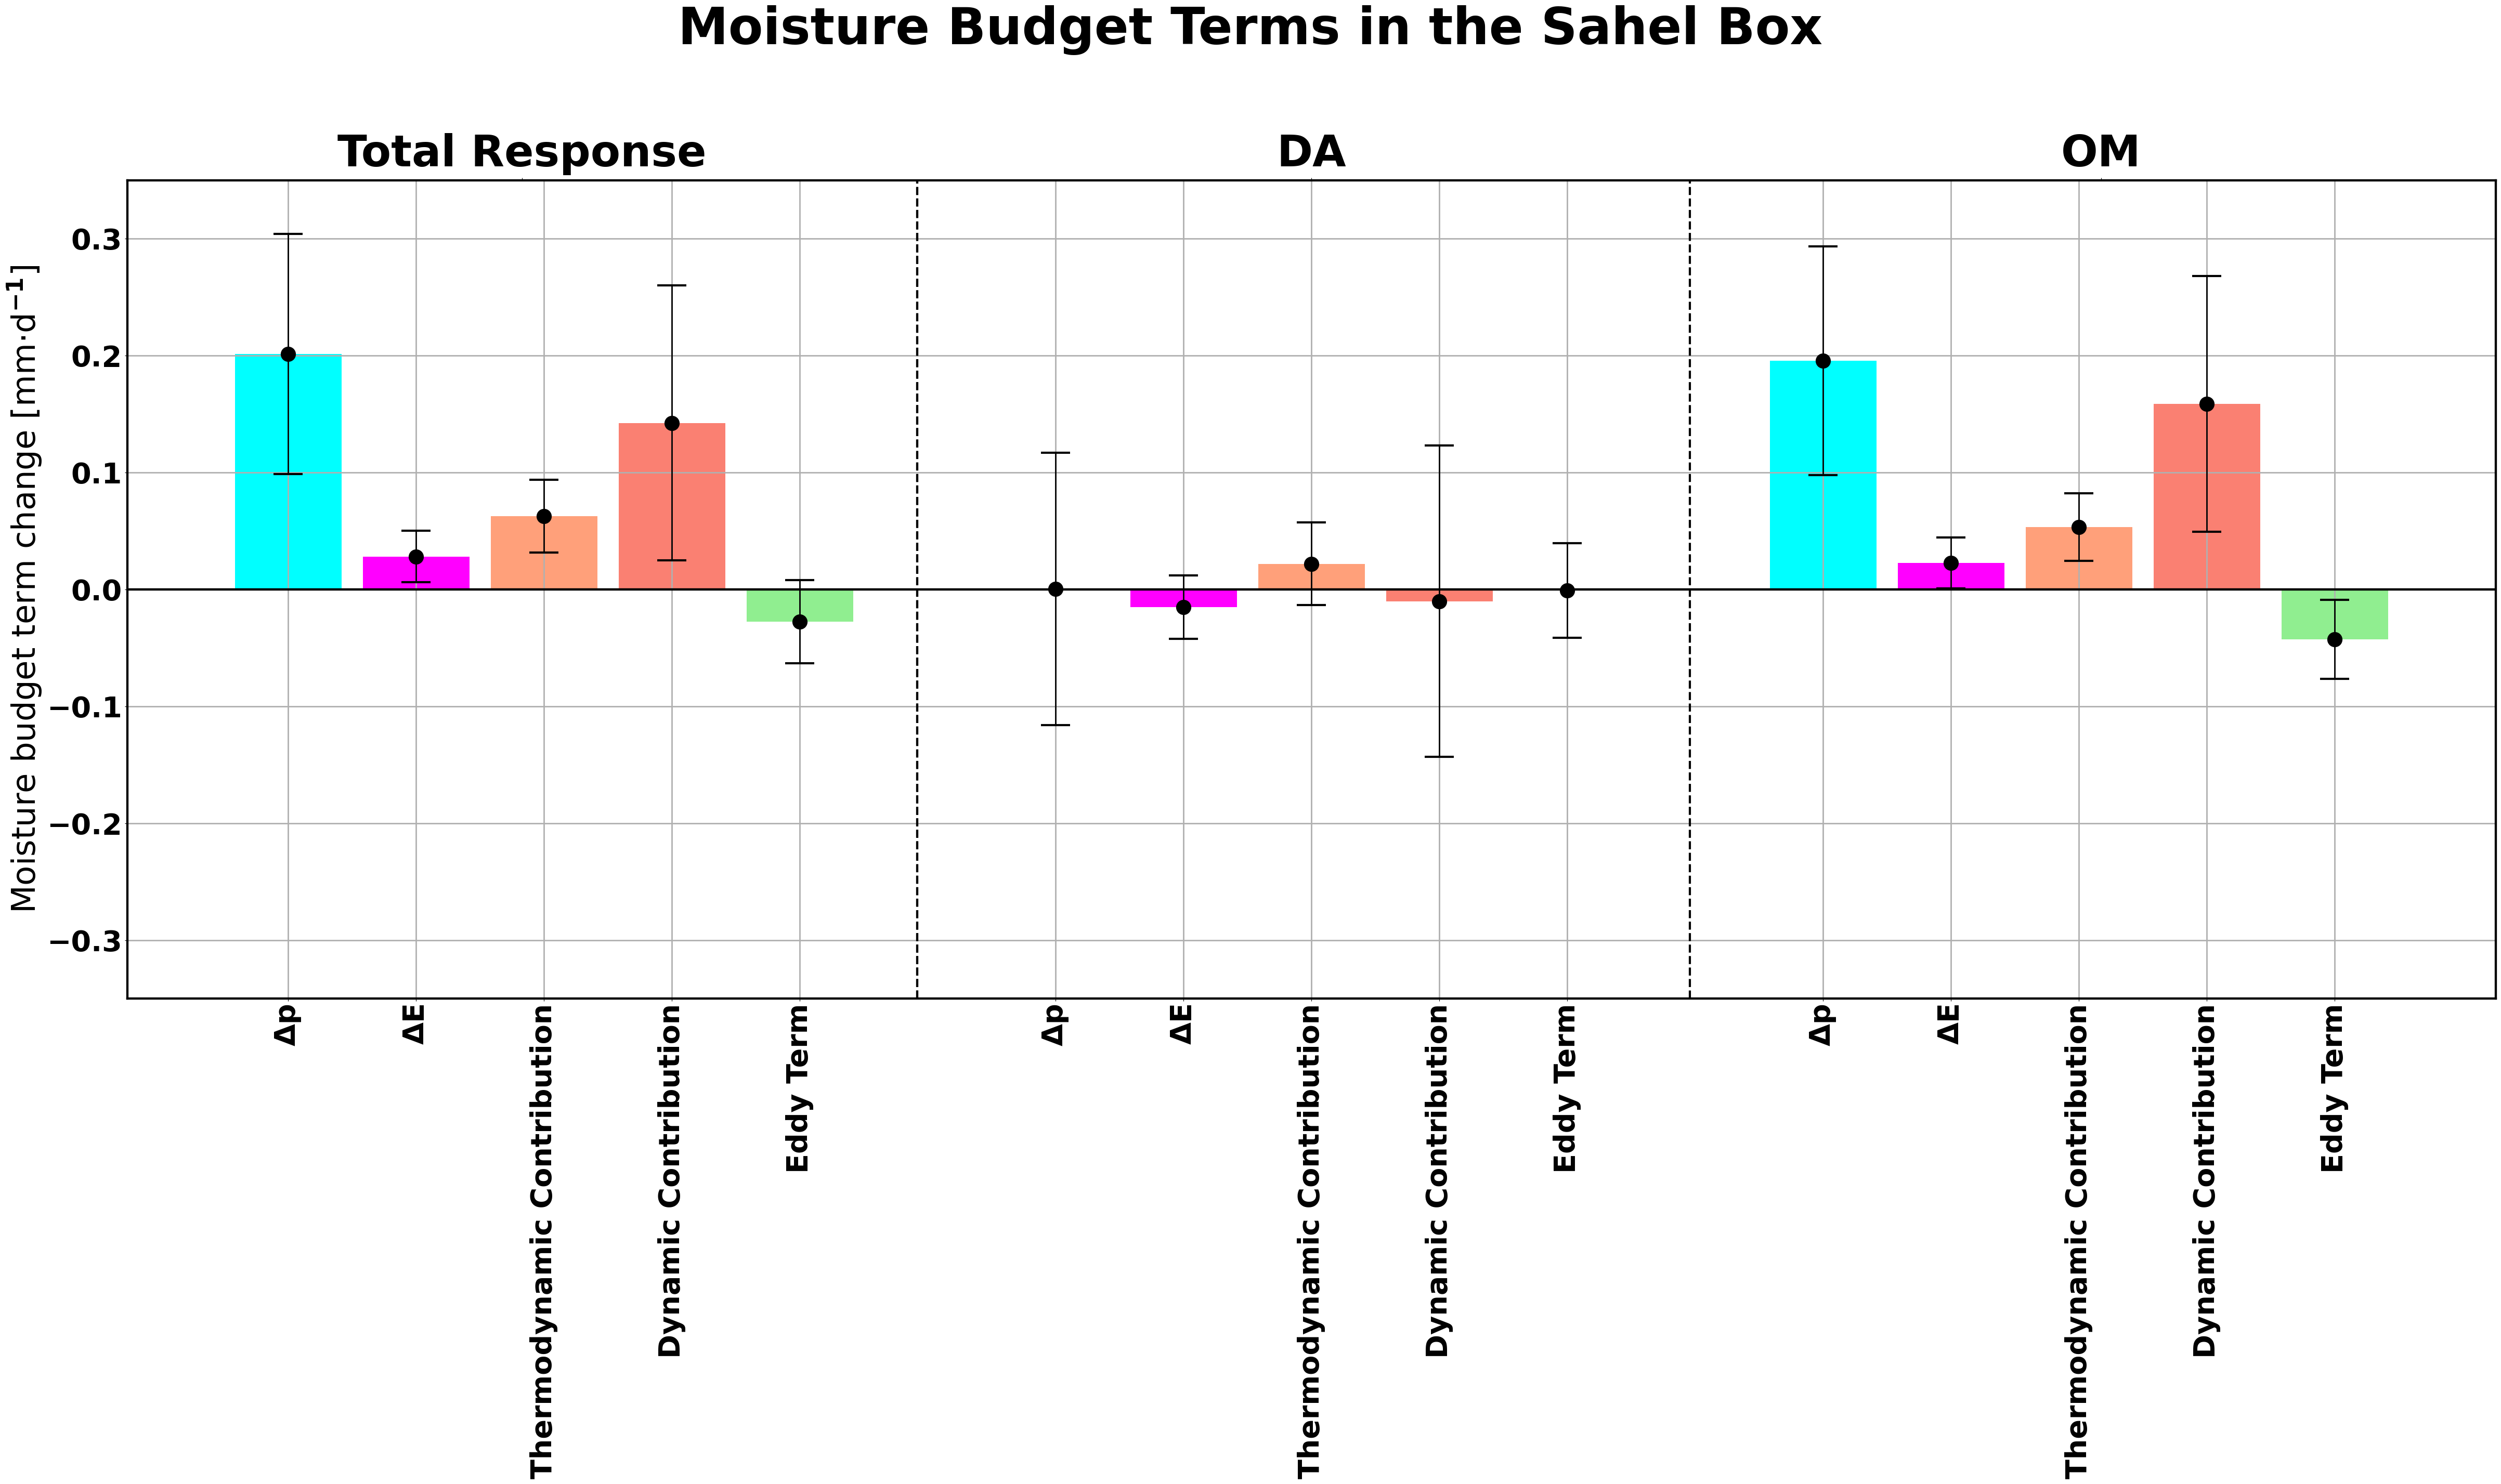

In [49]:
############ FOR AA BAR DIAGRAM ########################

fig = plt.figure(figsize=(50,30))
ft = 70


size_bars = 1
sep_groups = 0
location_vector_diff12_bar = np.asarray([size_bars/2 + 0.1, 3 * size_bars/2 + 0.3, 5 * size_bars/2 + 0.5, 7 * size_bars/2 + 0.7, 9 * size_bars/2 + 0.9])
location_vector_diff32_bar = np.asarray([11 * size_bars/2 + 1.3 +1, 13 * size_bars/2 + 1.5+1, 15 * size_bars/2 + 1.7+1,17 * size_bars/2 + 1.9+1,19 * size_bars/2 + 2.1+1])
location_vector_diff52_bar = np.asarray([21 * size_bars/2 + 2.5 +2, 23 * size_bars/2 + 2.7+2, 25 * size_bars/2 + 2.9+2,27 * size_bars/2 + 3.1+2,29 * size_bars/2 + 3.3+2])

# Calculo vectores de máscara para representar la significación estadística



color = ['cyan', 'magenta', 'lightsalmon', 'salmon', 'lightgreen', 'green', 'blue', 'red','orange']


ax1 = fig.add_subplot(1,1,1)


ax1.bar(location_vector_diff12_bar, [dprecip_ctrlaer2004, devap_ctrlaer2004, dtherm_cont_ctrlaer2004, ddyn_cont_ctrlaer2004, deddy_ctrlaer2004] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff32_bar, [dprecip_aerda2004, devap_aerda2004, dtherm_cont_aerda2004,  ddyn_cont_aerda2004, deddy_aerda2004] , width = size_bars, align = 'center', color = color)
ax1.bar(location_vector_diff52_bar, [dprecip_aerom2004, devap_aerom2004, dtherm_cont_aerom2004,  ddyn_cont_aerom2004, deddy_aerom2004] , width = size_bars, align = 'center', color = color)



ax1.errorbar(location_vector_diff12_bar, [dprecip_ctrlaer2004, devap_ctrlaer2004, dtherm_cont_ctrlaer2004, ddyn_cont_ctrlaer2004, deddy_ctrlaer2004] , yerr= yerr_ctrlaer , fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff32_bar, [dprecip_aerda2004, devap_aerda2004, dtherm_cont_aerda2004, ddyn_cont_aerda2004, deddy_aerda2004],  yerr= yerr_aerda, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )
ax1.errorbar(location_vector_diff52_bar, [dprecip_aerom2004, devap_aerom2004, dtherm_cont_aerom2004, ddyn_cont_aerom2004, deddy_aerom2004],  yerr= yerr_aerom, fmt='o', ecolor='black', markerfacecolor = 'black', markeredgecolor = 'black', markersize = 20,capsize=20,capthick=3,elinewidth=2 )





ax1.set_ylabel(r'Moisture budget term change [mm·d$^{-1}$]', fontsize = 45)
ax1.set_xticks(np.concatenate([location_vector_diff12_bar, location_vector_diff32_bar, location_vector_diff52_bar]))
ax1.set_xticklabels([r'', r'', r'', r'', r'', r'', r'', r'', r'',r'',r'',r'',r'',r'',r''], rotation = 90)



ax1.grid(linewidth = 2)
#ax1.axvline(x = 16* size_bars/2 + 0.1 + 2 + 4 * sep_groups+3, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )

ax1.set_ylim([-0.35, 0.35])
#ax2 = ax1.twiny()
#ax2.set_xlim([0,3.8])
#ax2.set_xticks([0.8, 2.8])
#ax2.set_xticklabels(['', ''], fontsize = ft -10 )

#ax1.set_title('CTRLGHG2004 $-$ CTRLGHG1980', fontsize = 70, weight = 'bold')

ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax1.grid(linewidth = 2)
ax1.axvline(x = 10 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axvline(x = 24.5 * size_bars/2 + 1.5, linewidth = 3, linestyle = '--', color = 'black' )
ax1.axhline(y = 0, linewidth = 3, color = 'black' )


ax2 = ax1.twiny()
ax2.set_xlim([0,3])
ax2.set_xticks([0.5, 1.5, 2.5])
ax2.set_xticklabels(['Total Response', 'DA', 'OM'], fontsize = ft -10 )

fig.suptitle('Moisture Budget Terms in the Sahel Box', fontsize = 70, weight = 'bold')

ax1.set_xticklabels([r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term', r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term', r'$\Delta$p', r'$\Delta$E', r'Thermodynamic Contribution', r'Dynamic Contribution', r'Eddy Term'], rotation = 90)

fig.tight_layout()

plt.savefig('/home/pfernand/Postdoc/Results/Forced_simulations/GHG/Moisture_budget/Moisture_budget_AA_thermodynamic_dynamic.jpg', bbox_inches = 'tight', dpi = 150)

